# Grain-Boundary Structure → Thermal Boundary Resistance

Analysis and ML pipeline built on the dataset produced by
`ml/format_cleaned_data.py` (`dataset.csv`). One row per grain boundary:

- **Geometry / identity** — `gb_label`, `sigma`, `gb_character` (twist / tilt /
  mixed), `tilt_type`, `misorientation_deg`, `inclination_deg`
- **Disorder descriptors** (atom subsets `full` and `gb10`) —
  `{subset}_sigma_theta`, `_sigma_l`, `_H_phi`, `_A_RDF`, `_rho`
- **GB energy** — `gamma_j_m2`, `gamma_ev_ang2`, …
- **rNEMD targets** — `R_K_mean` (Kapitza resistance ≡ thermal boundary
  resistance, TBR), `kappa_mean`, …

> Twist/tilt character and the misorientation/inclination angles are computed
> upstream by `utils/gb_geometry.py` and read straight from the CSV — this
> notebook never re-derives them. SOAP / Kernel-PCA / UMAP from the old pipeline
> have been removed (those columns no longer exist).

In [1]:
import os

# ---- Resource caps (set BEFORE importing numpy / sklearn) ----------------
# Keep BLAS/OpenMP single-threaded so their thread pools don't multiply
# against joblib workers. On a shared login node an uncapped
# threads x workers explosion can exhaust memory and get the kernel
# (and the VS Code server) OOM-killed.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- Configuration -------------------------------------------------------
DATASET = "/projects/p33174/PSED_results/full/dataset.csv"
SUBSET  = "gb10"          # atom subset used for the "measures of disorder"
TARGET  = "R_K_mean"      # thermal boundary resistance (Kapitza resistance)
RANDOM_STATE = 42

# TBR is stored in m^2 K / W (~1e-9). Rescale into m^2 K / GW so the target
# and its errors are O(1). TARGET_LABEL is reused on every axis showing R_K.
TBR_SCALE    = 1e9
TBR_UNIT     = r"m$^2$K/GW"
TARGET_LABEL = f"{TARGET} ({TBR_UNIT})"

# Bounded parallelism for GridSearchCV -- NOT -1 (= every core on the node).
# On a shared login node n_jobs=-1 spawns ~50 workers and can OOM the node;
# raise this via the PSED_N_JOBS env var when on a dedicated compute node.
N_JOBS = int(os.environ.get("PSED_N_JOBS", "4"))

# Repeated-CV evaluation protocol, shared across every section that trains a
# model so the out-of-sample R^2 numbers are directly comparable.
N_SPLITS, N_REPEATS = 10, 20

# The five structural measures of disorder (per subset).
DESC_NAMES  = ["sigma_theta", "sigma_l", "H_phi", "A_RDF", "rho"]
DESC_COLS   = [f"{SUBSET}_{m}" for m in DESC_NAMES]
DESC_LABELS = {
    f"{SUBSET}_sigma_theta": r"$\sigma_\theta$ (deg)",
    f"{SUBSET}_sigma_l":     r"$\sigma_l$ (Å)",
    f"{SUBSET}_H_phi":       r"$H_\phi$ (nats)",
    f"{SUBSET}_A_RDF":       r"$A_\mathrm{RDF}$",
    f"{SUBSET}_rho":         r"$\rho$ (atoms/Å³)",
}

# Consistent colors for GB character across every plot.
CHAR_COLORS = {"twist": "#1f77b4", "tilt": "#ff7f0e", "mixed": "#2ca02c"}

# ---- Load ----------------------------------------------------------------
df = pd.read_csv(DATASET)

# Rescale the TBR target (and its std) from m^2 K / W into m^2 K / GW.
for _c in (TARGET, "R_K_std"):
    if _c in df.columns:
        df[_c] = df[_c] * TBR_SCALE

print(f"Loaded {len(df)} grain boundaries x {df.shape[1]} columns")
print(f"Sigma values: {sorted(df['sigma'].unique())}")
print("\nGB character:\n" + df["gb_character"].value_counts().to_string())
print("\nTilt type:\n" + df["tilt_type"].value_counts(dropna=False).to_string())
print(f"\nRows with {TARGET}:     {df[TARGET].notna().sum()}/{len(df)}  (units: {TBR_UNIT})")
print(f"Rows with gamma_j_m2: {df['gamma_j_m2'].notna().sum()}/{len(df)}")

Loaded 73 grain boundaries x 36 columns
Sigma values: [np.int64(3), np.int64(5), np.int64(7), np.int64(9), np.int64(11), np.int64(13), np.int64(15), np.int64(17), np.int64(19), np.int64(21), np.int64(23), np.int64(25), np.int64(27), np.int64(29)]

GB character:
gb_character
tilt     52
twist    21

Tilt type:
tilt_type
symmetric     41
NaN           21
asymmetric    11

Rows with R_K_mean:     48/73  (units: m$^2$K/GW)
Rows with gamma_j_m2: 0/73


## 1. Distributions of the gb10 disorder descriptors

Histograms of the five structural measures computed over atoms within 10 Å of
the grain-boundary plane.

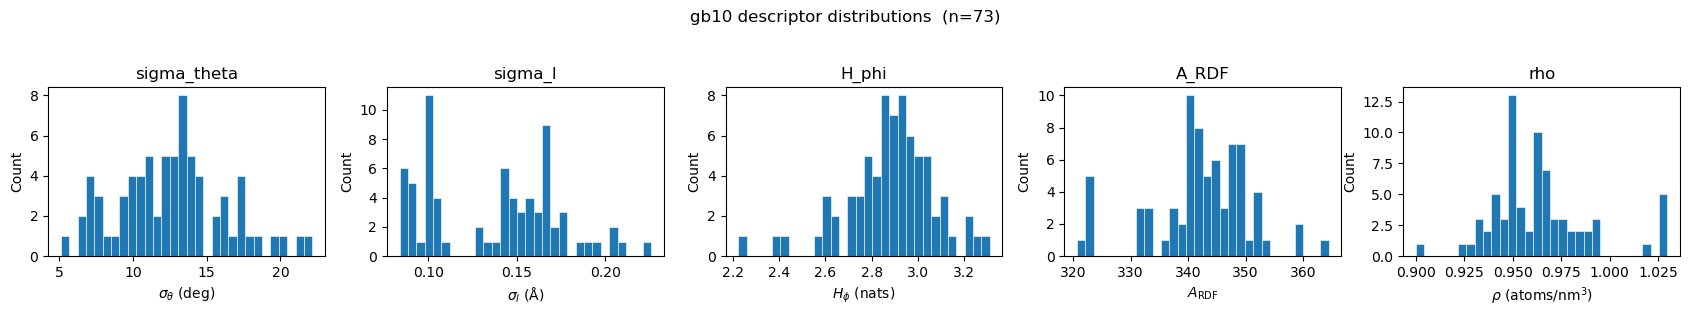

In [2]:
# Display rho in atoms/nm^3 (stored as atoms/Å^3; 1 nm^3 = 1000 Å^3).
# Local to this plot only -- df stays in Å^3 for PCA / ML.
rho_col = f"{SUBSET}_rho"
DISPLAY_SCALE  = {rho_col: 1e3}
DISPLAY_LABELS = {**DESC_LABELS, rho_col: r"$\rho$ (atoms/nm$^3$)"}

present = [c for c in DESC_COLS if c in df.columns]
fig, axes = plt.subplots(1, len(present), figsize=(3.4 * len(present), 3))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, present):
    vals = df[col].dropna() * DISPLAY_SCALE.get(col, 1.0)
    ax.hist(vals, bins=min(30, max(5, len(vals))), edgecolor="white", linewidth=0.4)
    ax.set_xlabel(DISPLAY_LABELS.get(col, col))
    ax.set_ylabel("Count")
    ax.set_title(col.replace(f"{SUBSET}_", ""))
fig.suptitle(f"{SUBSET} descriptor distributions  (n={len(df)})", y=1.04)
fig.tight_layout()
plt.show()

## 2. PCA of the disorder measures, colored by GB character

Standardize the five gb10 descriptors and project onto the first two principal
components. Points are colored by twist/tilt character (primary), with a
sigma-colored panel for context. The loading matrix shows which descriptors
drive each PC.

Explained variance ratio: [0.619 0.33 ]

Loadings:
               PC1    PC2
sigma_theta  0.515  0.304
sigma_l      0.533  0.160
H_phi        0.482  0.316
A_RDF        0.389 -0.559
rho         -0.257  0.685


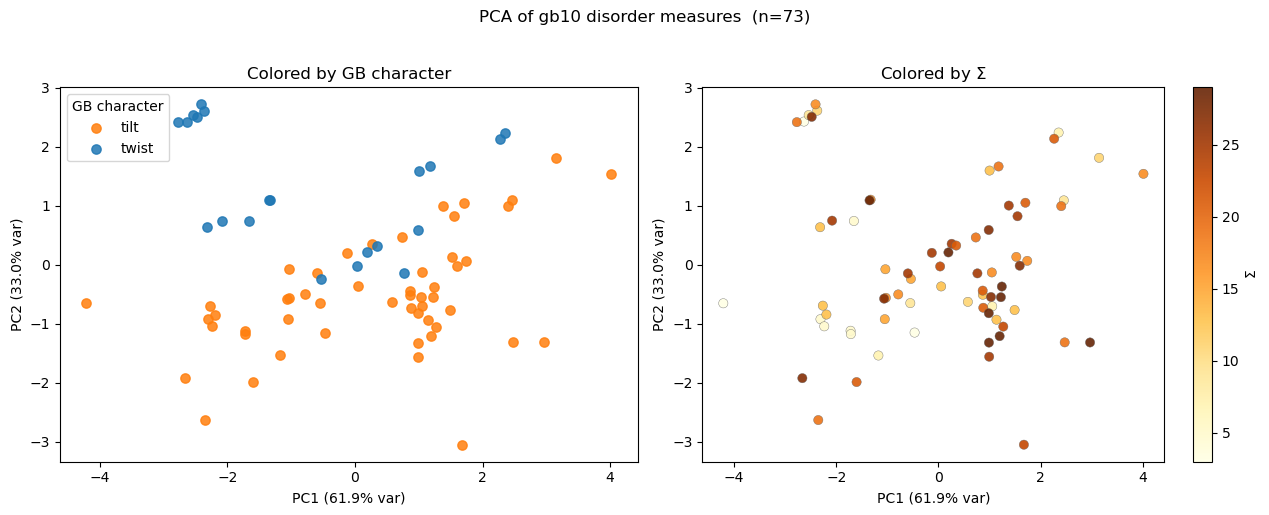

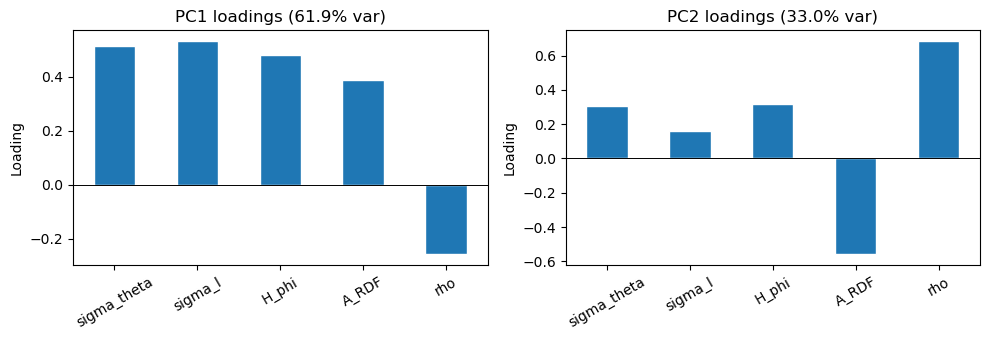

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_mask = df[DESC_COLS].notna().all(axis=1)
X_desc = df.loc[pca_mask, DESC_COLS].values
chars  = df.loc[pca_mask, "gb_character"].values
sigmas = df.loc[pca_mask, "sigma"].values

if len(X_desc) < 3:
    print(f"Only {len(X_desc)} rows with complete descriptors (need >=3). Skipping PCA.")
else:
    X_scaled = StandardScaler().fit_transform(X_desc)
    pca = PCA(n_components=2).fit(X_scaled)
    X_pca = pca.transform(X_scaled)
    evr = pca.explained_variance_ratio_

    loadings = pd.DataFrame(
        pca.components_.T,
        index=[c.replace(f"{SUBSET}_", "") for c in DESC_COLS],
        columns=["PC1", "PC2"],
    )
    print("Explained variance ratio:", np.round(evr, 3))
    print("\nLoadings:\n" + loadings.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ch in pd.unique(chars):
        m = chars == ch
        axes[0].scatter(X_pca[m, 0], X_pca[m, 1], s=45, alpha=0.85,
                        color=CHAR_COLORS.get(ch, "gray"), label=ch)
    axes[0].legend(title="GB character")
    axes[0].set_title("Colored by GB character")
    sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=sigmas, cmap="YlOrBr",
                         s=45, alpha=0.9, edgecolor="0.4", linewidth=0.3)
    plt.colorbar(sc, ax=axes[1], label="$\\Sigma$")
    axes[1].set_title("Colored by $\\Sigma$")
    for ax in axes:
        ax.set_xlabel(f"PC1 ({evr[0]:.1%} var)")
        ax.set_ylabel(f"PC2 ({evr[1]:.1%} var)")
    fig.suptitle(f"PCA of {SUBSET} disorder measures  (n={len(X_pca)})", y=1.02)
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    for ax, pc in zip(axes, ["PC1", "PC2"]):
        loadings[pc].plot(kind="bar", ax=ax, edgecolor="white")
        ax.axhline(0, color="k", linewidth=0.7)
        ax.set_title(f"{pc} loadings ({evr[int(pc[-1]) - 1]:.1%} var)")
        ax.set_ylabel("Loading")
        ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()

## 4. GB energy vs thermal boundary resistance

Relationship between the relaxed GB formation energy `gamma_j_m2` ($\gamma$) and
the Kapitza resistance `R_K_mean`. Error bars use the per-GB std columns where
available.

In [4]:
ev = df[df["gamma_j_m2"].notna() & df[TARGET].notna()]
if len(ev) == 0:
    print("GB energy (gamma_j_m2) not yet computed for any row with a target --"
          " skipping the gamma-R_K relationship. (Re-run once GB energies fill in.)")
else:
    x = ev["gamma_j_m2"].to_numpy()
    y = ev[TARGET].to_numpy()
    yerr = ev["R_K_std"].to_numpy() if "R_K_std" in ev else None

    fig, ax = plt.subplots(figsize=(6.5, 5))
    for ch in pd.unique(ev["gb_character"]):
        m = (ev["gb_character"] == ch).to_numpy()
        ax.errorbar(x[m], y[m], yerr=None if yerr is None else yerr[m],
                    fmt="o", ms=6, alpha=0.85, capsize=2,
                    color=CHAR_COLORS.get(ch, "gray"), label=ch)
    ax.set_xlabel(r"$\gamma$ (J/m$^2$)"); ax.set_ylabel(TARGET_LABEL)
    ax.set_title("GB energy vs TBR")
    ax.legend(title="GB character")
    fig.tight_layout()
    plt.show()

    if len(ev) >= 3:
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)
        print(f"Pearson  r = {r_p:+.3f}  (p = {p_p:.3g})")
        print(f"Spearman rho = {r_s:+.3f}  (p = {p_s:.3g})")
    else:
        print(f"Only {len(ev)} points -- correlation not meaningful.")

GB energy (gamma_j_m2) not yet computed for any row with a target -- skipping the gamma-R_K relationship. (Re-run once GB energies fill in.)


## 5. Misorientation angle vs R_K

Misorientation is fixed per (axis, $\Sigma$) and sets the lattice mismatch
across the boundary. Here we check whether it tracks `R_K` on its own
(Spearman, monotonic). Inclination is dropped — it is NaN for twist/mixed and
~0 for symmetric tilt, so it covers only a third of the target rows and carries
little signal.

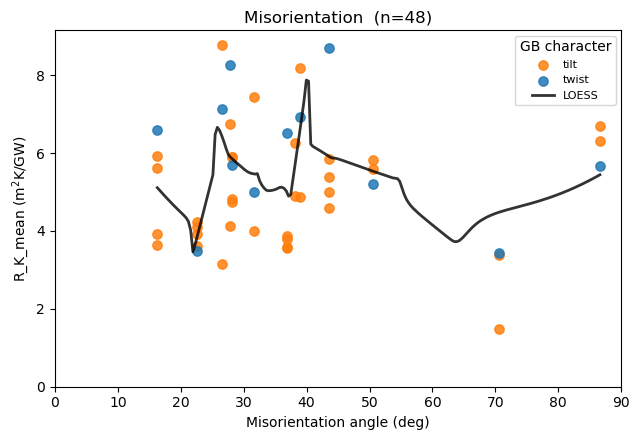

In [5]:
angle_col, title = "misorientation_deg", "Misorientation"
sub = df[df[angle_col].notna() & df[TARGET].notna()]


def _loess(x, y, frac=0.2, n_out=200):
    """Tricube-weighted local linear regression (LOESS). Self-contained — the
    chem env has no statsmodels. `frac` = fraction of points in each local
    window. Returns (xs, ys) for a smooth curve over the data range."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    xs = np.linspace(x.min(), x.max(), n_out)
    k = max(int(np.ceil(frac * len(x))), 3)
    ys = np.empty_like(xs)
    for i, x0 in enumerate(xs):
        d = np.abs(x - x0)
        h = np.sort(d)[k - 1] or 1.0           # distance to k-th nearest
        w = (1 - np.clip(d / h, 0, 1) ** 3) ** 3   # tricube weights
        sw = w.sum()
        if sw <= 0:
            ys[i] = np.nan; continue
        mx = (w * x).sum() / sw; my = (w * y).sum() / sw
        bxx = (w * (x - mx) ** 2).sum()
        b = (w * (x - mx) * (y - my)).sum() / bxx if bxx > 1e-12 else 0.0
        ys[i] = my + b * (x0 - mx)
    return xs, ys


fig, ax = plt.subplots(figsize=(6.5, 4.5))
if len(sub) == 0:
    ax.text(0.5, 0.5, f"No data for {angle_col}", ha="center", va="center",
            transform=ax.transAxes)
    ax.set_title(title)
else:
    for ch in pd.unique(sub["gb_character"]):
        m = sub["gb_character"] == ch
        ax.scatter(sub.loc[m, angle_col], sub.loc[m, TARGET], s=45, alpha=0.85,
                   color=CHAR_COLORS.get(ch, "gray"), label=ch)
    # LOESS trend over all characters: if angle determined R_K it would slope;
    # a flat/wiggly line reflects that misorientation is only 1 of a GB's 5
    # macroscopic DOF (see section 12).
    if sub[angle_col].nunique() >= 4 and len(sub) >= 6:
        xs, ys = _loess(sub[angle_col], sub[TARGET], frac=0.3)
        ax.plot(xs, ys, color="k", lw=2, alpha=0.8, label="LOESS", zorder=5)
    ax.set_xlabel(f"{title} angle (deg)"); ax.set_ylabel(TARGET_LABEL)
    ax.set_xlim(0, 90)
    ax.set_ylim(bottom=0)
    ax.legend(title="GB character", fontsize=8)
    if sub[angle_col].nunique() >= 3 and len(sub) >= 3:
        r_s, p_s = stats.spearmanr(sub[angle_col], sub[TARGET])
        ax.set_title(f"{title}  (n={len(sub)})")
    else:
        ax.set_title(f"{title}  (n={len(sub)}, {sub[angle_col].nunique()} unique x)")
fig.tight_layout()
plt.show()


## 5b. Linear vs quadratic regression on the 2D PCA coordinates

Section 2 projects the five gb10 scalars onto two principal components. Here we
keep that **linear** PCA(2) embedding and ask whether `R_K` is better explained
by a **linear** or a **quadratic** model in those two coordinates:

- **linear** — $R_K \sim \mathrm{PC1} + \mathrm{PC2}$
- **quadratic** — $R_K \sim \mathrm{PC1} + \mathrm{PC2} + \mathrm{PC1}^2 +
  \mathrm{PC2}^2 + \mathrm{PC1}\,\mathrm{PC2}$  (squares + interaction)

Both are ridge-regularized linear regressions (`RidgeCV` picks $\alpha$ per
fold) on the **same** two coordinates — only the feature set differs, so any gap
is genuine curvature, not a different learner. The PCA and the polynomial
expansion live inside the pipeline, refit per CV fold (no leakage); a 5-scalar
linear ridge is the reference. The first figure shows the data in PC space and
the fitted quadratic response surface; the learning curve then compares
out-of-sample $R^2$.

PCA-coord regression: 48 GBs, 5 scalars -> 2 PCs
PCA(2) explains 94.7% of the 5-scalar variance (PC1 64.2%, PC2 30.5%)


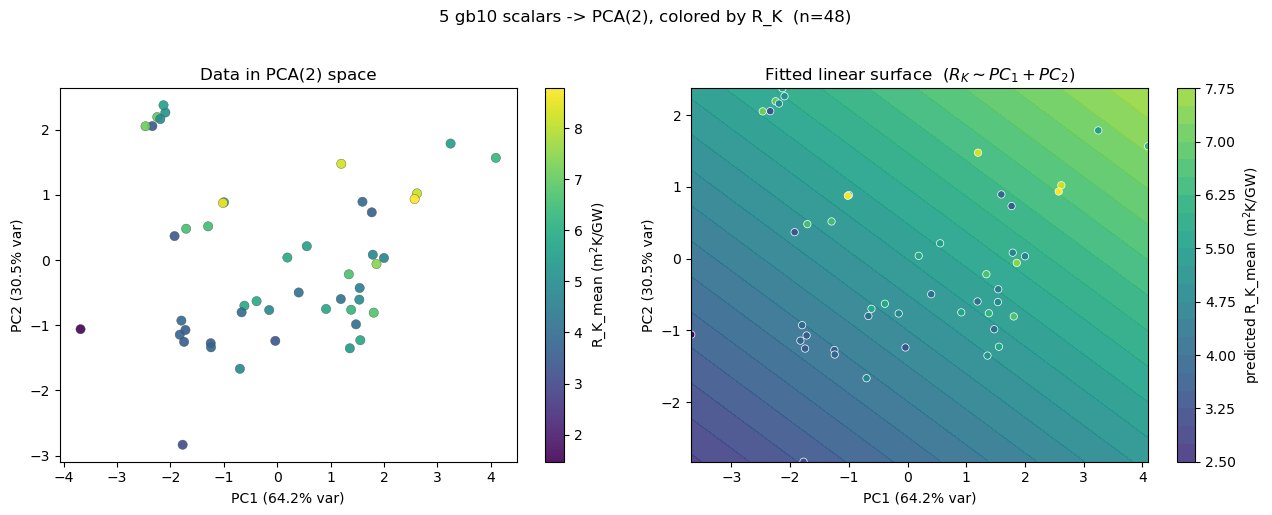

  5 scalars (linear)   R2 @ full = -0.154
  PC1,PC2 (linear)     R2 @ full = -0.209
  PC1,PC2 (quadratic)  R2 @ full = -0.232


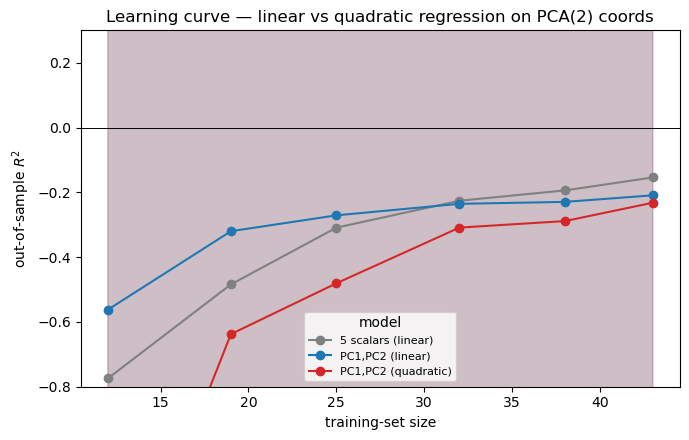

In [6]:
# Linear PCA(2) of the 5 gb10 scalars -> coordinates (PC1, PC2). Then compare a
# LINEAR vs a QUADRATIC regression MODEL on those two coordinates:
#   linear     R_K ~ PC1 + PC2
#   quadratic  R_K ~ PC1 + PC2 + PC1^2 + PC2^2 + PC1*PC2
# Same RidgeCV estimator throughout, so any gap is curvature -- not the learner.
# PCA + poly sit INSIDE the pipeline so both are refit per CV fold (no leakage).
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, RepeatedKFold, learning_curve

emb_mask = df[DESC_COLS].notna().all(axis=1) & df[TARGET].notna()
Xs = df.loc[emb_mask, DESC_COLS].to_numpy()
ye = df.loc[emb_mask, TARGET].to_numpy()
print(f"PCA-coord regression: {emb_mask.sum()} GBs, {len(DESC_COLS)} scalars -> 2 PCs")

ALPHAS = np.logspace(-3, 3, 13)  # RidgeCV grid, per-fold leave-one-out alpha

# --- linear PCA(2) embedding (fit on all rows, for the scatter + surface) -----
emb = Pipeline([("sc", StandardScaler()),
                ("pca", PCA(n_components=2, random_state=RANDOM_STATE))])
Z = emb.fit_transform(Xs)
evr = emb.named_steps["pca"].explained_variance_ratio_
print(f"PCA(2) explains {evr.sum():.1%} of the 5-scalar variance "
      f"(PC1 {evr[0]:.1%}, PC2 {evr[1]:.1%})")

# Fit the linear model on all data once, purely to draw its response surface.
lin_all = RidgeCV(alphas=ALPHAS).fit(Z, ye)
gx, gy = np.meshgrid(np.linspace(Z[:, 0].min(), Z[:, 0].max(), 150),
                     np.linspace(Z[:, 1].min(), Z[:, 1].max(), 150))
gp = lin_all.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
vmin, vmax = ye.min(), ye.max()

# --- (a) data in PC space and the fitted linear surface ----------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc0 = axes[0].scatter(Z[:, 0], Z[:, 1], c=ye, cmap="viridis", vmin=vmin, vmax=vmax,
                      s=45, alpha=0.9, edgecolor="0.3", linewidth=0.3)
fig.colorbar(sc0, ax=axes[0], label=TARGET_LABEL)
axes[0].set_title("Data in PCA(2) space")
cf = axes[1].contourf(gx, gy, gp, levels=20, cmap="viridis", vmin=vmin, vmax=vmax, alpha=0.9)
fig.colorbar(cf, ax=axes[1], label=f"predicted {TARGET_LABEL}")
axes[1].scatter(Z[:, 0], Z[:, 1], c=ye, cmap="viridis", vmin=vmin, vmax=vmax,
                s=28, edgecolor="white", linewidth=0.5)
axes[1].set_title(r"Fitted linear surface  ($R_K \sim PC_1 + PC_2$)")
for ax in axes:
    ax.set_xlabel(f"PC1 ({evr[0]:.1%} var)"); ax.set_ylabel(f"PC2 ({evr[1]:.1%} var)")
fig.suptitle(f"5 gb10 scalars -> PCA(2), colored by R_K  (n={len(Z)})", y=1.02)
fig.tight_layout()
plt.show()

# --- (b) learning curves: linear vs quadratic model on the PCs (+5-scalar ref) -
models = {
    "5 scalars (linear)":  Pipeline([("sc", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
    "PC1,PC2 (linear)":    Pipeline([("sc", StandardScaler()),
                                     ("pca", PCA(2, random_state=RANDOM_STATE)),
                                     ("sc2", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
    "PC1,PC2 (quadratic)": Pipeline([("sc", StandardScaler()),
                                     ("pca", PCA(2, random_state=RANDOM_STATE)),
                                     ("poly", PolynomialFeatures(2, include_bias=False)),
                                     ("sc2", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
}
colors = {"5 scalars (linear)": "0.5", "PC1,PC2 (linear)": "#1f77b4",
          "PC1,PC2 (quadratic)": "#d62728"}
sizes = np.array([0.3, 0.45, 0.6, 0.75, 0.9, 1.0])

fig, ax = plt.subplots(figsize=(7, 4.5))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, pipe in models.items():
        ts, _, te = learning_curve(
            pipe, Xs, ye, train_sizes=sizes, scoring="r2", shuffle=True,
            random_state=RANDOM_STATE,
            cv=RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE))
        ax.plot(ts, te.mean(1), "o-", color=colors[name], label=name)
        ax.fill_between(ts, te.mean(1) - te.std(1), te.mean(1) + te.std(1),
                        color=colors[name], alpha=0.15)
        print(f"  {name:20s} R2 @ full = {te.mean(1)[-1]:+.3f}")
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("training-set size"); ax.set_ylabel("out-of-sample $R^2$")
ax.set_ylim(-0.8, 0.3)  # models overfit below ~20 GBs; clip the small-N dip
ax.set_title("Learning curve — linear vs quadratic regression on PCA(2) coords")
ax.legend(fontsize=8, title="model")
fig.tight_layout()
plt.show()

  PC1,PC2 (linear)     R2=+0.218 +/- 0.025  RMSE=1.386
  PC1,PC2 (quadratic)  R2=+0.199 +/- 0.045  RMSE=1.400


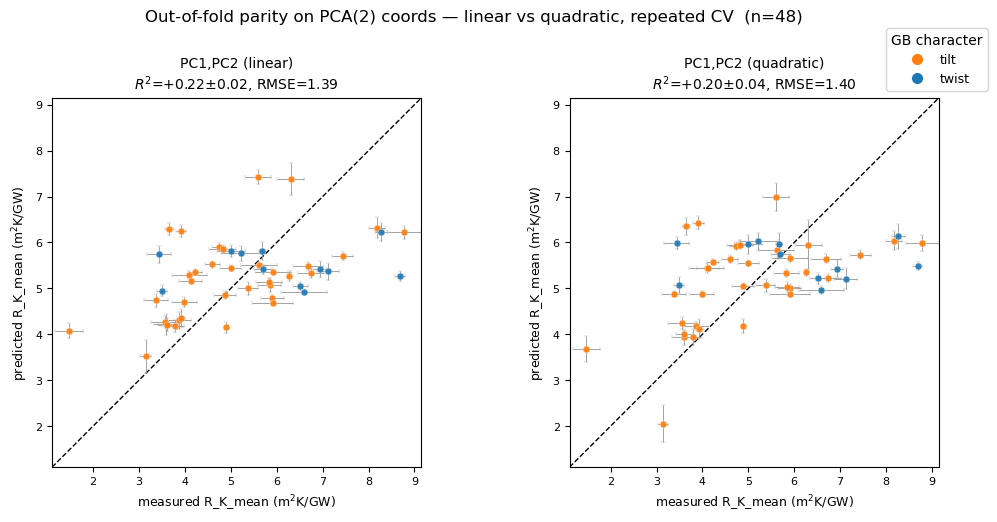

In [7]:
# --- (c) parity plots: out-of-fold predicted vs measured R_K ------------------
# Honest predictions for the SAME two PCA(2) models, under the shared repeated
# K-fold protocol (10-fold x 20 rep). PCA sits inside each pipeline -> refit per
# fold, no leakage. Each point is the prediction averaged over the replications;
# vertical bars = its spread across replications, horizontal bars = SEM of the
# measured mean R_K (replica std / sqrt(5)).
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error

parity_models = {
    "PC1,PC2 (linear)":    Pipeline([("sc", StandardScaler()),
                                     ("pca", PCA(2, random_state=RANDOM_STATE)),
                                     ("sc2", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
    "PC1,PC2 (quadratic)": Pipeline([("sc", StandardScaler()),
                                     ("pca", PCA(2, random_state=RANDOM_STATE)),
                                     ("poly", PolynomialFeatures(2, include_bias=False)),
                                     ("sc2", StandardScaler()),
                                     ("m", RidgeCV(alphas=ALPHAS))]),
}
chars = df.loc[emb_mask, "gb_character"].to_numpy()
sem_meas = np.nan_to_num(df.loc[emb_mask, "R_K_std"].to_numpy(), nan=0.0) / np.sqrt(5)
n_e = len(ye)

# Repeated K-fold OOF: average each point's prediction over replications, and
# collect one pooled R^2 per replication (mean +/- std reported on the panel).
oof, oof_sd, r2_reps = {}, {}, {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, pipe in parity_models.items():
        rkf = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
        psum = np.zeros(n_e); psq = np.zeros(n_e); pcnt = np.zeros(n_e)
        r2s = []; pred_rep = np.full(n_e, np.nan); k = 0
        for tr, te in rkf.split(Xs):
            pipe.fit(Xs[tr], ye[tr]); p = pipe.predict(Xs[te])
            pred_rep[te] = p; psum[te] += p; psq[te] += p ** 2; pcnt[te] += 1; k += 1
            if k == N_SPLITS:
                r2s.append(r2_score(ye, pred_rep)); pred_rep = np.full(n_e, np.nan); k = 0
        oof[name] = psum / pcnt
        oof_sd[name] = np.sqrt(np.maximum(psq / pcnt - oof[name] ** 2, 0.0))
        r2_reps[name] = np.array(r2s)

# shared, square axis limits across both panels
allv = np.concatenate([ye, *oof.values()])
lo, hi = allv.min(), allv.max()
pad = 0.05 * (hi - lo); lo, hi = lo - pad, hi + pad

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5), squeeze=False)
for ax, name in zip(axes.ravel(), parity_models):
    pred = oof[name]
    r2 = r2_reps[name].mean(); r2sd = r2_reps[name].std()
    rmse = np.sqrt(mean_squared_error(ye, pred))
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=1)
    for ch in pd.unique(chars):
        m = chars == ch
        ax.errorbar(ye[m], pred[m], xerr=sem_meas[m], yerr=oof_sd[name][m], fmt="o",
                    ms=5, alpha=0.9, color=CHAR_COLORS.get(ch, "gray"), ecolor="0.6",
                    elinewidth=0.7, capsize=1.5, mec="white", mew=0.3, label=ch, zorder=2)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel(f"measured {TARGET_LABEL}", fontsize=9)
    ax.set_ylabel(f"predicted {TARGET_LABEL}", fontsize=9)
    ax.set_title(f"{name}\n$R^2$={r2:+.2f}$\\pm${r2sd:.2f}, RMSE={rmse:.2f}", fontsize=10)
    ax.tick_params(labelsize=8)
    print(f"  {name:20s} R2={r2:+.3f} +/- {r2sd:.3f}  RMSE={rmse:.3f}")

handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=7,
                      color=CHAR_COLORS.get(ch, "gray"), label=ch)
           for ch in pd.unique(chars)]
fig.legend(handles=handles, title="GB character", loc="upper right",
           bbox_to_anchor=(0.995, 0.995), fontsize=9)
fig.suptitle(f"Out-of-fold parity on PCA(2) coords — linear vs quadratic, repeated CV  (n={len(ye)})",
             y=1.02)
fig.tight_layout()
plt.show()


## 5c. The same angle, different R_K — colored by Σ

A grain boundary has **five macroscopic degrees of freedom** (rotation axis +
boundary-plane normal + misorientation angle); the angle is only one of them. So
R_K cannot be a function of angle alone — boundaries at nearly the same
misorientation but different Σ / plane scatter widely in R_K. The near-zero
Spearman correlation makes it quantitative: **macroscopic crystallography does not
predict the thermal boundary resistance**, which is exactly why the descriptors of
the *realized local structure* (sections 11b/11c) succeed where it fails.


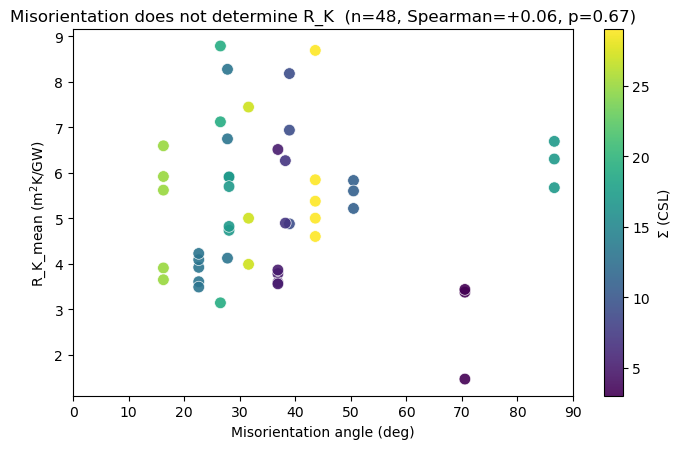

In [8]:
# Section 5c -- the same misorientation angle gives very different R_K depending
# on Sigma / boundary plane: angle is only 1 of a GB's 5 macroscopic DOF.
sub = df[df["misorientation_deg"].notna() & df[TARGET].notna()]

fig, ax = plt.subplots(figsize=(7, 4.6))
sc = ax.scatter(sub["misorientation_deg"], sub[TARGET], c=sub["sigma"],
                cmap="viridis", s=70, alpha=0.9, edgecolor="white", linewidth=0.5)
cbar = fig.colorbar(sc, ax=ax); cbar.set_label(r"$\Sigma$ (CSL)")
ax.set_xlim(0, 90)
ax.set_xlabel("Misorientation angle (deg)"); ax.set_ylabel(TARGET_LABEL)
r_s, p_s = stats.spearmanr(sub["misorientation_deg"], sub[TARGET])
ax.set_title(f"Misorientation does not determine R_K  "
             f"(n={len(sub)}, Spearman={r_s:+.2f}, p={p_s:.2f})")
fig.tight_layout(); plt.show()


## 6. Descriptor–R_K pairplot

Pairwise relationships among the five gb10 disorder descriptors and the target
`R_K_mean`, colored by twist/tilt character. The diagonal shows each variable's
distribution; the **bottom row / right column** isolate each descriptor's
relationship to the thermal boundary resistance. ($\rho$ is shown in
atoms/nm³ to match section 1.)

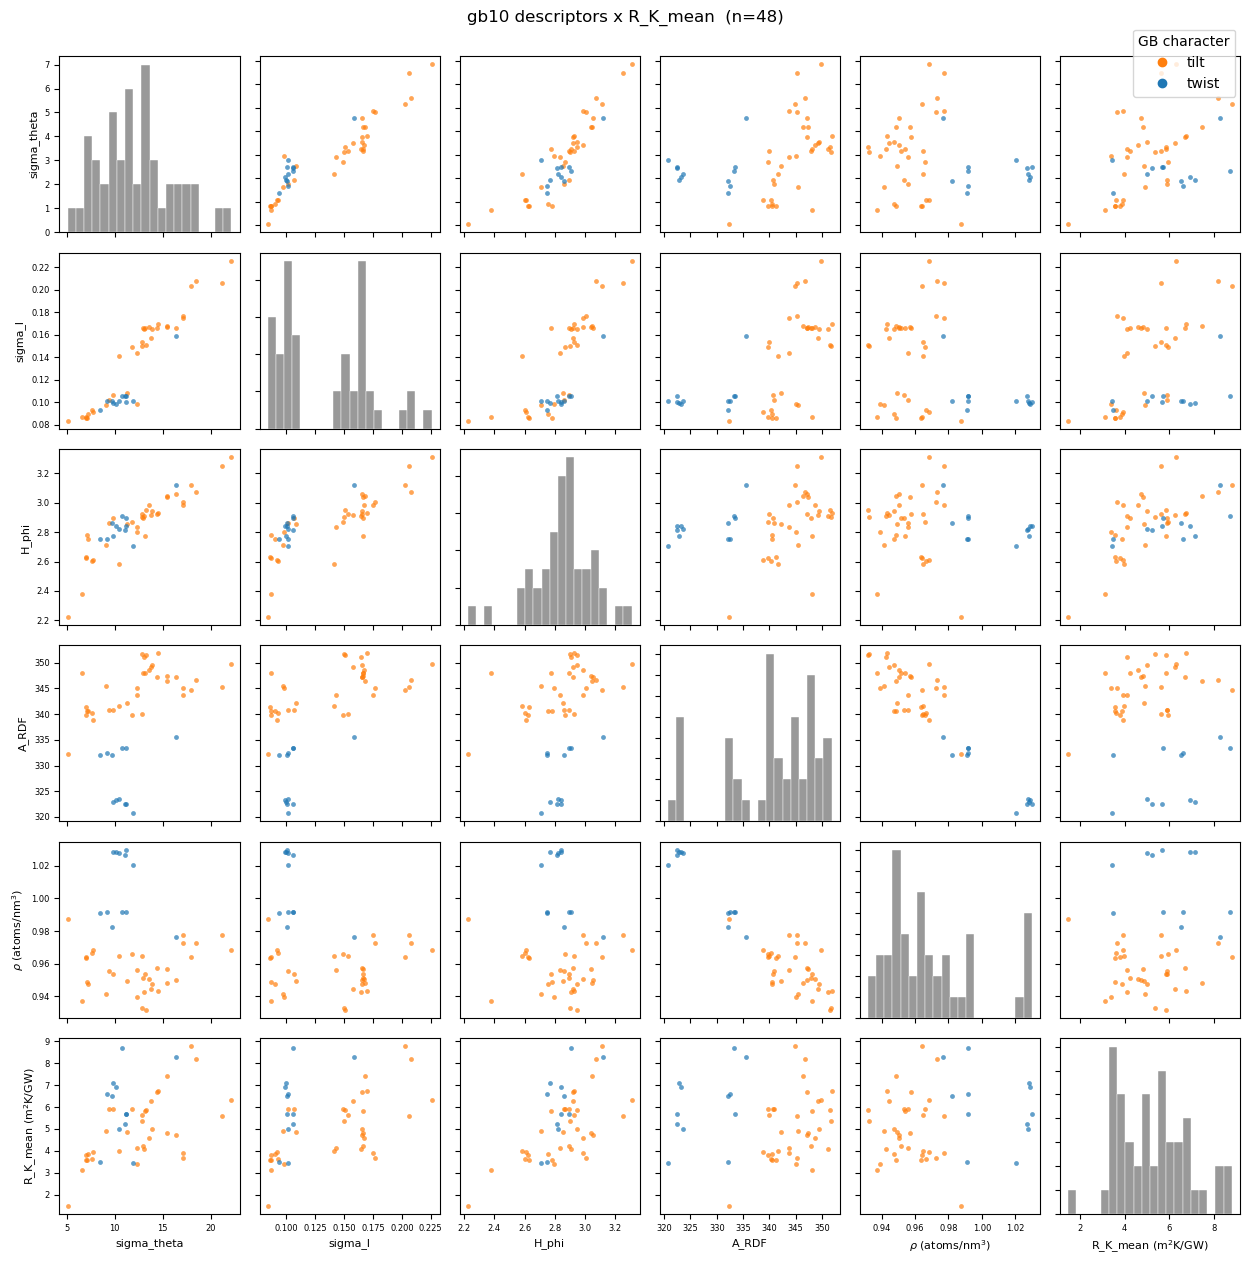

In [9]:
# Pairwise scatter matrix of the gb10 descriptors and R_K, colored by GB character.
# Diagonal = each variable's distribution; bottom row / right column = descriptor vs R_K.
pair_cols = DESC_COLS + [TARGET]
pp = df.dropna(subset=pair_cols)

if len(pp) < 3:
    print(f"Only {len(pp)} rows with all descriptors + {TARGET}; skipping pairplot.")
else:
    # rho shown in atoms/nm^3 (x1000) to match the section-1 distributions.
    PAIR_SCALE  = {f"{SUBSET}_rho": 1e3}
    PAIR_LABELS = {c: c.replace(f"{SUBSET}_", "") for c in DESC_COLS}
    PAIR_LABELS[f"{SUBSET}_rho"] = r"$\rho$ (atoms/nm$^3$)"
    PAIR_LABELS[TARGET] = TARGET_LABEL

    n = len(pair_cols)
    data  = {c: pp[c].to_numpy() * PAIR_SCALE.get(c, 1.0) for c in pair_cols}
    chars = pp["gb_character"].to_numpy()

    fig, axes = plt.subplots(n, n, figsize=(2.1 * n, 2.1 * n))
    for i, ci in enumerate(pair_cols):
        for j, cj in enumerate(pair_cols):
            ax = axes[i, j]
            if i == j:
                ax.hist(data[ci], bins=min(20, max(5, len(pp))),
                        color="0.6", edgecolor="white", linewidth=0.3)
            else:
                for ch in pd.unique(chars):
                    m = chars == ch
                    ax.scatter(data[cj][m], data[ci][m], s=12, alpha=0.7,
                               color=CHAR_COLORS.get(ch, "gray"), linewidth=0)
            ax.tick_params(labelsize=6)
            ax.set_xlabel(PAIR_LABELS[cj], fontsize=8) if i == n - 1 else ax.set_xticklabels([])
            ax.set_ylabel(PAIR_LABELS[ci], fontsize=8) if j == 0 else ax.set_yticklabels([])

    handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=6,
                          color=CHAR_COLORS.get(ch, "gray"), label=ch)
               for ch in pd.unique(chars)]
    fig.legend(handles=handles, title="GB character",
               loc="upper right", bbox_to_anchor=(0.99, 0.99))
    fig.suptitle(f"{SUBSET} descriptors x {TARGET}  (n={len(pp)})", y=1.0)
    fig.tight_layout()
    plt.show()

## 7. Predicting R_K — multi-model regression with nested CV

With only ~50 grain boundaries, a single held-out test set is too noisy. We
estimate out-of-sample error with **nested cross-validation**:

- **Outer loop** — shuffled `KFold`. Each outer fold yields a genuine
  out-of-sample score.
- **Inner loop** — `GridSearchCV` tunes each model's hyperparameters using only
  the outer-training data (no leakage).

Models: Ridge, KNN, RandomForest, XGBoost, a **Ridge+KNN averaging ensemble**
(best out-of-sample RMSE in our tests — a linear + a local learner whose errors
partly cancel), and a mean baseline. Features are the five gb10 disorder
measures **plus two macroscopic-geometry features** (misorientation angle and
$\Sigma$), which give the distance/linear models a small but real edge. Target
is `R_K_mean`.

> Two transforms we tried and dropped (no gain once predictions were scored
> back in raw m²K/GW space): a **log-transformed target** (the raw target is
> already roughly symmetric) and adding the **`full`-subset descriptors** (they
> are collinear with the gb10 ones and inflated variance). See section 9 for
> which features actually carry signal.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, RepeatedKFold, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# Five gb10 disorder measures + two macroscopic-geometry features. Geometry is
# fully populated on the target rows (no rows lost) and helps the linear/local
# models; see section 9 for the per-feature importance.
GEOM_FEATURES = ["misorientation_deg", "sigma"]
FEATURES = list(DESC_COLS) + GEOM_FEATURES

mldf = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
X = mldf[FEATURES].to_numpy()
y = mldf[TARGET].to_numpy()
print(f"Modeling on {len(mldf)} GBs, {len(FEATURES)} features, target = {TARGET}")

# Per-model CV protocol. The default repeated 10-fold x 20-rep (N_SPLITS /
# N_REPEATS, set in the config cell) is shared by every section (8, 11, 11b, 12)
# so the R^2 numbers are directly comparable. RandomForest / XGBoost grid-search
# is ~10-50x slower, so they use a lighter 5-fold x 10-rep -- they were already
# shown not to beat Ridge/KNN, this just keeps sections 7-8 fast.
HEAVY_CV = {"RandomForest": (5, 10), "XGBoost": (5, 10)}
def model_cv(name):
    return HEAVY_CV.get(name, (N_SPLITS, N_REPEATS))


def build_models():
    '''name -> (pipeline, param_grid). Scaler is harmless for trees, needed for
    Ridge / KNN / the ensemble.'''
    return {
        "Ridge": (
            Pipeline([("sc", StandardScaler()), ("m", Ridge())]),
            {"m__alpha": [1e-3, 1e-2, 1e-1, 1, 10, 100]},
        ),
        "KNN": (
            Pipeline([("sc", StandardScaler()), ("m", KNeighborsRegressor())]),
            {"m__n_neighbors": [3, 5, 7, 9], "m__weights": ["uniform", "distance"]},
        ),
        "RandomForest": (
            Pipeline([("sc", StandardScaler()),
                      ("m", RandomForestRegressor(random_state=RANDOM_STATE))]),
            {"m__n_estimators": [200, 400], "m__max_depth": [None, 3, 5],
             "m__max_features": ["sqrt", 1.0]},
        ),
        "XGBoost": (
            Pipeline([("sc", StandardScaler()),
                      ("m", XGBRegressor(random_state=RANDOM_STATE, n_jobs=1,
                                         objective="reg:squarederror"))]),
            {"m__n_estimators": [200, 400], "m__max_depth": [2, 3],
             "m__learning_rate": [0.03, 0.1], "m__subsample": [0.8, 1.0]},
        ),
        # Average a linear (Ridge) and a local (KNN) learner: their errors are
        # partly independent, so the mean has lower variance -- best
        # out-of-sample RMSE on this small, noisy dataset.
        "Ridge+KNN": (
            Pipeline([("sc", StandardScaler()),
                      ("m", VotingRegressor([("ridge", Ridge()),
                                             ("knn", KNeighborsRegressor())]))]),
            {"m__ridge__alpha": [0.1, 1, 10],
             "m__knn__n_neighbors": [5, 7, 9],
             "m__knn__weights": ["uniform", "distance"]},
        ),
        "Baseline (mean)": (
            Pipeline([("m", DummyRegressor(strategy="mean"))]),
            {},
        ),
    }


def repeated_oof(Xmat, y_target, pipe, grid, n_splits, n_repeats):
    '''Repeated K-fold CV for ONE model. Within each replication every row is
    held out exactly once -> one pooled R2/RMSE/MAE per replication; per-point
    predictions are averaged over replications (pmean) with their spread (pstd).
    `grid` may be None/empty for a self-tuning or fixed estimator. Returns
    (pmean, pstd, r2s, rmses, maes), the last three being per-replication arrays.
    Shared by sections 5b, 7/8, 11 and 11b so every CV uses the same protocol.'''
    n = len(y_target)
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    psum = np.zeros(n); psq = np.zeros(n); pcnt = np.zeros(n)
    r2s = []; rmses = []; maes = []; oof = np.full(n, np.nan); k = 0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for tr, te in rkf.split(Xmat):
            if grid:
                s = GridSearchCV(pipe, grid, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                                 scoring="neg_root_mean_squared_error", n_jobs=N_JOBS)
                s.fit(Xmat[tr], y_target[tr]); est = s.best_estimator_
            else:
                est = pipe.fit(Xmat[tr], y_target[tr])
            p = est.predict(Xmat[te]); oof[te] = p
            psum[te] += p; psq[te] += p ** 2; pcnt[te] += 1; k += 1
            if k == n_splits:
                r2s.append(r2_score(y_target, oof))
                rmses.append(np.sqrt(mean_squared_error(y_target, oof)))
                maes.append(mean_absolute_error(y_target, oof))
                oof = np.full(n, np.nan); k = 0
    pmean = psum / pcnt; pstd = np.sqrt(np.maximum(psq / pcnt - pmean ** 2, 0.0))
    return pmean, pstd, np.array(r2s), np.array(rmses), np.array(maes)


def nested_cv(y_target, target_label=""):
    '''Repeated K-fold CV over every model in build_models() (per-model protocol
    via model_cv), reusing the global feature matrix X. Returns
    (results_df, oof_pred, oof_std): results_df = per-model pooled R2/RMSE/MAE
    (mean +/- std over replications) + the protocol used; oof_pred / oof_std =
    per-GB prediction averaged over replications and its spread (for the
    section-8 parity error bars). Returns (None, None, None) if too few rows.'''
    if len(mldf) < N_SPLITS:
        print(f"Only {len(mldf)} usable rows (< {N_SPLITS}); skipping CV.")
        return None, None, None
    hv = HEAVY_CV.get("RandomForest", (N_SPLITS, N_REPEATS))
    print(f"Repeated CV: {N_SPLITS}-fold x {N_REPEATS} rep "
          f"(RF/XGB: {hv[0]}-fold x {hv[1]} rep)"
          + (f"  |  target = {target_label}" if target_label else "") + "\n")
    rows = []; oof_pred = {}; oof_std = {}
    for name, (pipe, grid) in build_models().items():
        ns, nr = model_cv(name)
        pm, ps, r2s, rmses, maes = repeated_oof(X, y_target, pipe, grid, ns, nr)
        oof_pred[name] = pm; oof_std[name] = ps
        rows.append({"model": name,
                     "R2_mean": r2s.mean(), "R2_std": r2s.std(),
                     "RMSE_mean": rmses.mean(), "RMSE_std": rmses.std(),
                     "MAE_mean": maes.mean(), "MAE_std": maes.std(),
                     "protocol": f"{ns}fx{nr}r"})
        print(f"  {name:16s} R2={r2s.mean():+.3f} +/- {r2s.std():.3f}   "
              f"RMSE={rmses.mean():.3f}   [{ns}f x {nr}r]")
    return pd.DataFrame(rows).set_index("model"), oof_pred, oof_std


Modeling on 48 GBs, 7 features, target = R_K_mean


In [11]:
cv_results, oof_pred, oof_std = nested_cv(y, target_label=f"{TARGET} ({TBR_UNIT})")

if cv_results is not None:
    print("\n=== Repeated-CV out-of-sample performance ===")
    print(cv_results.round(4).to_string())


Repeated CV: 10-fold x 20 rep (RF/XGB: 5-fold x 10 rep)  |  target = R_K_mean (m$^2$K/GW)

  Ridge            R2=+0.226 +/- 0.061   RMSE=1.386   [10f x 20r]
  KNN              R2=+0.196 +/- 0.056   RMSE=1.412   [10f x 20r]
  RandomForest     R2=+0.207 +/- 0.065   RMSE=1.403   [5f x 10r]
  XGBoost          R2=+0.059 +/- 0.130   RMSE=1.525   [5f x 10r]
  Ridge+KNN        R2=+0.264 +/- 0.044   RMSE=1.352   [10f x 20r]
  Baseline (mean)  R2=-0.045 +/- 0.016   RMSE=1.611   [10f x 20r]

=== Repeated-CV out-of-sample performance ===
                 R2_mean  R2_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std protocol
model                                                                            
Ridge             0.2259  0.0612     1.3857    0.0543    1.1587   0.0460  10fx20r
KNN               0.1961  0.0562     1.4123    0.0495    1.1372   0.0438  10fx20r
RandomForest      0.2065  0.0651     1.4028    0.0572    1.1555   0.0425   5fx10r
XGBoost           0.0589  0.1299     1.5255    0.1043    1

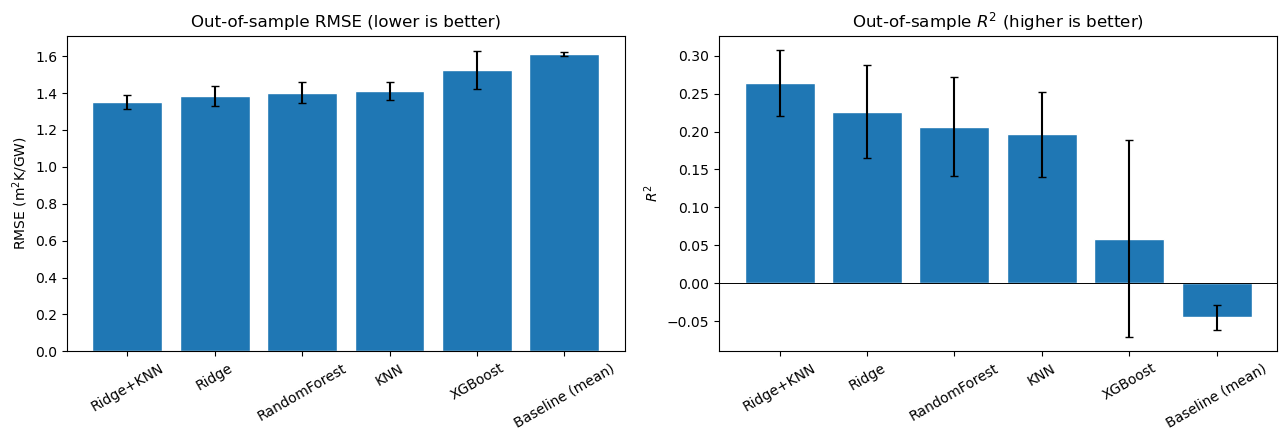

In [12]:
if cv_results is None:
    print("No CV results to plot.")
else:
    order = cv_results["RMSE_mean"].sort_values().index
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].bar(order, cv_results.loc[order, "RMSE_mean"],
                yerr=cv_results.loc[order, "RMSE_std"], capsize=3, edgecolor="white")
    axes[0].set_ylabel(f"RMSE ({TBR_UNIT})")
    axes[0].set_title("Out-of-sample RMSE (lower is better)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[1].bar(order, cv_results.loc[order, "R2_mean"],
                yerr=cv_results.loc[order, "R2_std"], capsize=3, edgecolor="white")
    axes[1].axhline(0, color="k", linewidth=0.7)
    axes[1].set_ylabel("$R^2$"); axes[1].set_title("Out-of-sample $R^2$ (higher is better)")
    axes[1].tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()

## 8. Parity plots — predicted vs measured R_K (out-of-fold)

Each panel pools the **out-of-fold** predictions from the nested-CV outer loop:
every GB is predicted by the fold in which it was held out, so nothing is
in-sample. The dashed line is the 1:1 ideal; the grey band is ±1 RMSE. $R^2$
and RMSE annotate each model, and points are colored by GB character. With ~50
GBs and weak structural signal these clouds are wide — the parity view exposes
the spread, any systematic over/under-prediction, and which GBs are outliers
far better than a single $R^2$ number does.

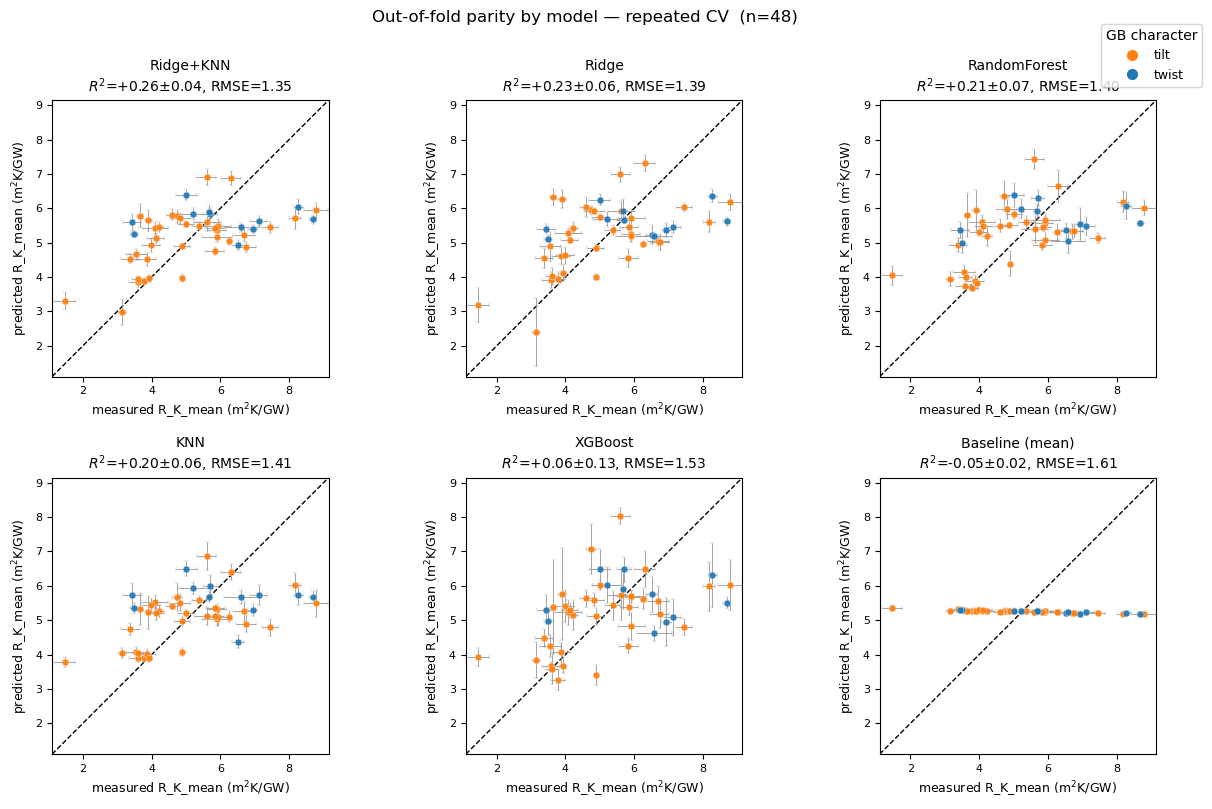

In [13]:
if cv_results is None:
    print("No CV results to plot.")
else:
    # One parity panel per model, ordered best-RMSE first. Each point is the
    # prediction averaged over the CV replications; vertical bars = its spread
    # across replications, horizontal bars = SEM of the measured mean R_K
    # (replica std / sqrt(5)).
    order = cv_results["RMSE_mean"].sort_values().index.tolist()
    chars = mldf["gb_character"].to_numpy()
    sem_meas = np.nan_to_num(mldf["R_K_std"].to_numpy(), nan=0.0) / np.sqrt(5)

    lo = min(y.min(), min(np.nanmin(oof_pred[m]) for m in order))
    hi = max(y.max(), max(np.nanmax(oof_pred[m]) for m in order))
    pad = 0.05 * (hi - lo)
    lo, hi = lo - pad, hi + pad

    ncols = 3
    nrows = int(np.ceil(len(order) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows),
                             squeeze=False)
    for ax, name in zip(axes.ravel(), order):
        pred = oof_pred[name]
        rmse = cv_results.loc[name, "RMSE_mean"]
        r2   = cv_results.loc[name, "R2_mean"]
        r2sd = cv_results.loc[name, "R2_std"]
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=1)
        for ch in pd.unique(chars):
            m = chars == ch
            ax.errorbar(y[m], pred[m], xerr=sem_meas[m], yerr=oof_std[name][m], fmt="o",
                        ms=5, alpha=0.9, color=CHAR_COLORS.get(ch, "gray"), ecolor="0.6",
                        elinewidth=0.7, capsize=1.5, mec="white", mew=0.3, label=ch, zorder=3)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
        ax.set_xlabel(f"measured {TARGET_LABEL}", fontsize=9)
        ax.set_ylabel(f"predicted {TARGET_LABEL}", fontsize=9)
        ax.set_title(f"{name}\n$R^2$={r2:+.2f}$\\pm${r2sd:.2f}, RMSE={rmse:.2f}", fontsize=10)
        ax.tick_params(labelsize=8)

    for ax in axes.ravel()[len(order):]:
        ax.axis("off")

    handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=7,
                          color=CHAR_COLORS.get(ch, "gray"), label=ch)
               for ch in pd.unique(chars)]
    fig.legend(handles=handles, title="GB character", loc="upper right",
               bbox_to_anchor=(0.995, 0.995), fontsize=9)
    fig.suptitle(f"Out-of-fold parity by model — repeated CV  (n={len(y)})", y=1.005)
    fig.tight_layout()
    plt.show()


## 10. How much is even predictable? — noise floor & learning curve

Before chasing a better model, two diagnostics that bound what is achievable:

- **Noise-floor ceiling.** `R_K_mean` is the average over 5 rNEMD replicas;
  `R_K_std` is their spread, so each GB's label has standard error
  $R\_K\_std/\sqrt{5}$. The fraction of the between-GB variance that is *not*
  replica noise is the ceiling on any model's $R^2$. It comes out **≈ 0.97** —
  the labels are precise, so almost all of the variance is, in principle,
  learnable.
- **Learning curve.** Out-of-sample $R^2$ vs training-set size for the best
  (Ridge+KNN) model. It climbs to ~0.2 by ~30 GBs and then **flattens**: with
  the current features, more data buys little, and we sit *far* below the 0.97
  ceiling. The gap is **missing descriptor signal**, not noise and not (mostly)
  sample size.

Between-GB variance of R_K_mean:        2.537 (m$^2$K/GW)^2
Mean replica-noise variance of the mean: 0.0653
=> predictable-variance ceiling:  R^2 <= 0.974
   best model so far reaches R^2 ~ +0.26  ->  most learnable signal is still on the table.


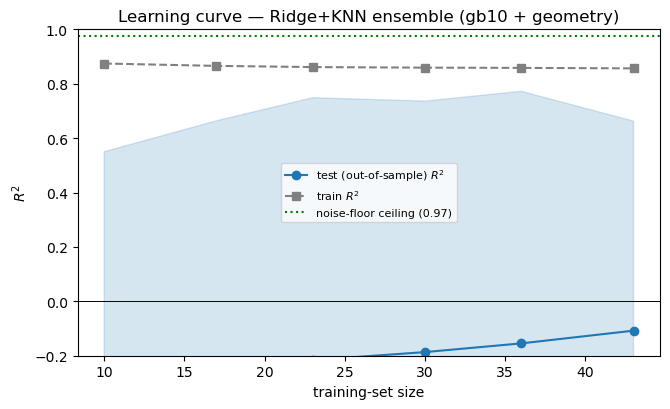

In [14]:
# (a) Predictable-variance ceiling from rNEMD replica noise, and
# (b) a learning curve for the best (ensemble) model.
from sklearn.model_selection import learning_curve, RepeatedKFold

if cv_results is None:
    print("No CV results -- skipping diagnostics.")
else:
    # --- (a) noise-floor ceiling -------------------------------------------
    # R_K_mean averages N_REPLICAS rNEMD runs; R_K_std (already in m^2K/GW) is
    # their spread, so SE of the mean = R_K_std / sqrt(N_REPLICAS). Label-noise
    # variance = mean(SE^2); ceiling R^2 = 1 - mean(SE^2)/var(R_K_mean).
    N_REPLICAS = 5
    tgt = df[df[TARGET].notna()]
    ceiling = None
    if "R_K_std" in df.columns and tgt["R_K_std"].notna().any():
        se2 = (tgt["R_K_std"] ** 2 / N_REPLICAS).mean()
        var_between = tgt[TARGET].var(ddof=1)
        ceiling = 1.0 - se2 / var_between
        print(f"Between-GB variance of {TARGET}:        {var_between:.3f} ({TBR_UNIT})^2")
        print(f"Mean replica-noise variance of the mean: {se2:.4f}")
        print(f"=> predictable-variance ceiling:  R^2 <= {ceiling:.3f}")
        print(f"   best model so far reaches R^2 ~ {cv_results['R2_mean'].max():+.2f}"
              f"  ->  most learnable signal is still on the table.")
    else:
        print("R_K_std unavailable; skipping noise-floor estimate.")

    # --- (b) learning curve -------------------------------------------------
    lc_pipe = Pipeline([("sc", StandardScaler()),
                        ("m", VotingRegressor([
                            ("ridge", Ridge(alpha=10)),
                            ("knn", KNeighborsRegressor(n_neighbors=7,
                                                        weights="distance"))]))])
    sizes = np.array([0.25, 0.4, 0.55, 0.7, 0.85, 1.0])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ts, tr_sc, te_sc = learning_curve(
            lc_pipe, X, y, train_sizes=sizes, scoring="r2", shuffle=True,
            random_state=RANDOM_STATE,
            cv=RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE))

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    ax.plot(ts, te_sc.mean(1), "o-", color="#1f77b4", label="test (out-of-sample) $R^2$")
    ax.fill_between(ts, te_sc.mean(1) - te_sc.std(1), te_sc.mean(1) + te_sc.std(1),
                    color="#1f77b4", alpha=0.18)
    ax.plot(ts, tr_sc.mean(1), "s--", color="0.5", label="train $R^2$")
    if ceiling is not None:
        ax.axhline(ceiling, color="green", ls=":",
                   label=f"noise-floor ceiling ({ceiling:.2f})")
    ax.axhline(0, color="k", lw=0.7)
    ax.set_xlabel("training-set size")
    ax.set_ylabel("$R^2$")
    ax.set_ylim(-0.2, 1.0)
    ax.set_title("Learning curve — Ridge+KNN ensemble (gb10 + geometry)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

## 11. Coordination-defect descriptors — the first real lift

The disorder *scalars* and SOAP all plateau near $R^2\approx0.2$ (section 10). A
physically sharper descriptor finally moves the needle: **coordination
defects**. Silicon is tetrahedral, so the fraction of under-/over-coordinated
atoms in the 10 Å GB slab — plus the mean/std of the coordination number —
directly counts the broken/strained bonding that scatters phonons.

These four `gb10_coord_*` features are computed by
`ml/compute_coordination.py` (cached to `ml/gb10_coordination.csv`) and are now
also emitted by `format_cleaned_data.py` for future dataset builds. Adding them
lifts the best out-of-sample $R^2$ by ~0.1 — e.g. KNN $0.13\!\to\!0.28$ here,
and $0.22\!\to\!0.30$ under repeated-seed pooled-OOF — **robust across CV seeds,
and the first descriptor change in this pipeline that beats the disorder
scalars.** (SOAP, by contrast, did not help: mean/anomaly pooling is diluted by
the bulk-like atoms that dominate the slab.)

Loaded ml/gb10_coordination.csv: coordination present for 48/48 modeled GBs

### scalars (gb10+geom)  (p=7)
           RMSE_mean  R2_mean  R2_std
Ridge         1.3857   0.2259  0.0612
KNN           1.4123   0.1961  0.0562
Ridge+KNN     1.3518   0.2638  0.0437

### coordination only  (p=4)
           RMSE_mean  R2_mean  R2_std
Ridge         1.5138   0.0766  0.0595
KNN           1.3201   0.2972  0.0592
Ridge+KNN     1.3453   0.2708  0.0453

### scalars + coordination  (p=11)
           RMSE_mean  R2_mean  R2_std
Ridge         1.3522   0.2626  0.0629
KNN           1.4429   0.1607  0.0661
Ridge+KNN     1.3342   0.2825  0.0535

Best: KNN on 'coordination only'  ->  R2=+0.297


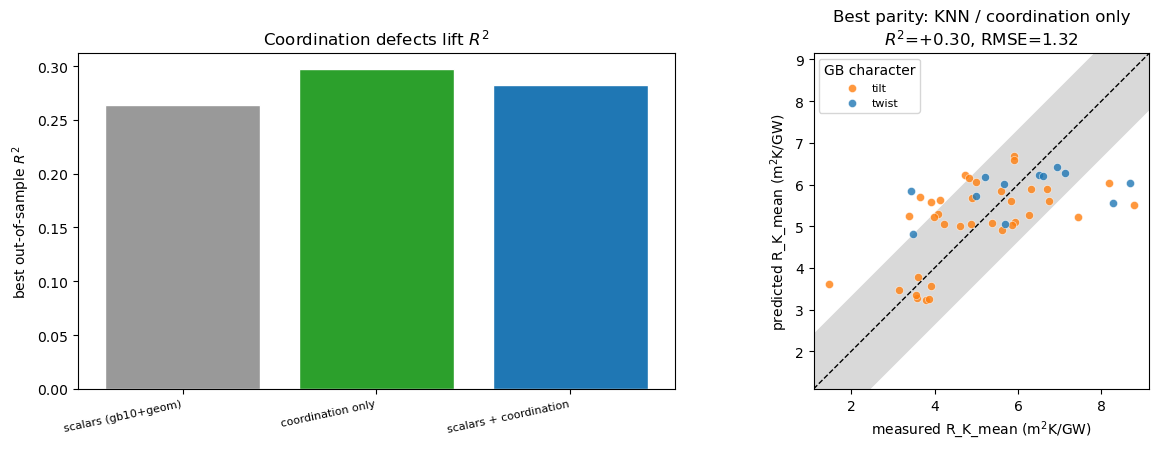

In [15]:
# Coordination-defect lift: compare scalars / coordination / both under the
# same repeated 10-fold x 20-rep CV as section 7. Reads the
# ml/compute_coordination.py cache.
import os

COORD_COLS = [f"{SUBSET}_coord_{s}" for s in ("under", "over", "mean", "std")]
_cache_candidates = ["ml/gb10_coordination.csv", "gb10_coordination.csv",
                     os.path.join(os.path.dirname(DATASET), "gb10_coordination.csv")]
COORD_CACHE = next((p for p in _cache_candidates if os.path.exists(p)), None)

if cv_results is None:
    print("No base CV results; skipping coordination comparison.")
elif COORD_CACHE is None:
    print("Coordination cache not found. Generate it with:")
    print("    python ml/compute_coordination.py")
    print(f"(looked in: {_cache_candidates})")
else:
    coord_df = pd.read_csv(COORD_CACHE)
    mc = mldf.merge(coord_df, on="gb_label", how="left")
    ok = mc[COORD_COLS].notna().all(axis=1).to_numpy()
    print(f"Loaded {COORD_CACHE}: coordination present for {ok.sum()}/{len(mc)} modeled GBs")

    yc = mc.loc[ok, TARGET].to_numpy()
    feat_sets = {
        "scalars (gb10+geom)":    mc.loc[ok, FEATURES].to_numpy(),
        "coordination only":      mc.loc[ok, COORD_COLS].to_numpy(),
        "scalars + coordination": mc.loc[ok, FEATURES + COORD_COLS].to_numpy(),
    }
    cmp_models = {k: build_models()[k] for k in ("Ridge", "KNN", "Ridge+KNN")}

    def coord_cv(Xmat):
        # Repeated 10-fold x 20-rep (shared repeated_oof); pooled R2 per rep.
        res, oof = {}, {}
        for name, (pipe, grid) in cmp_models.items():
            pm, ps, r2s, rmses, _ = repeated_oof(Xmat, yc, pipe, grid, N_SPLITS, N_REPEATS)
            res[name] = {"RMSE_mean": rmses.mean(), "R2_mean": r2s.mean(), "R2_std": r2s.std()}
            oof[name] = pm
        return pd.DataFrame(res).T, oof

    tables, oofs = {}, {}
    for label, Xm in feat_sets.items():
        tables[label], oofs[label] = coord_cv(Xm)
        print(f"\n### {label}  (p={Xm.shape[1]})")
        print(tables[label].round(4).to_string())

    bfs, bm = max(((fs, m) for fs in tables for m in tables[fs].index),
                  key=lambda km: tables[km[0]].loc[km[1], "R2_mean"])
    print(f"\nBest: {bm} on '{bfs}'  ->  R2={tables[bfs].loc[bm,'R2_mean']:+.3f}")

    # (a) best-R2 per feature set; (b) parity for the best combo
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    fs_names = list(feat_sets)
    best_r2 = [tables[fs]["R2_mean"].max() for fs in fs_names]
    axes[0].bar(range(len(fs_names)), best_r2,
                color=["0.6", "#2ca02c", "#1f77b4"], edgecolor="white")
    axes[0].set_xticks(range(len(fs_names)))
    axes[0].set_xticklabels(fs_names, rotation=12, ha="right", fontsize=8)
    axes[0].axhline(0, color="k", lw=0.7)
    axes[0].set_ylabel("best out-of-sample $R^2$")
    axes[0].set_title("Coordination defects lift $R^2$")

    pr = oofs[bfs][bm]; rmse = tables[bfs].loc[bm, "RMSE_mean"]
    lo = min(yc.min(), np.nanmin(pr)); hi = max(yc.max(), np.nanmax(pr))
    pad = 0.05 * (hi - lo); lo, hi = lo - pad, hi + pad
    chars = mc.loc[ok, "gb_character"].to_numpy()
    ax = axes[1]
    ax.fill_between([lo, hi], [lo - rmse, hi - rmse], [lo + rmse, hi + rmse],
                    color="0.85", zorder=0)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    for ch in pd.unique(chars):
        m = chars == ch
        ax.scatter(yc[m], pr[m], s=34, alpha=0.8, color=CHAR_COLORS.get(ch, "gray"),
                   edgecolor="white", linewidth=0.4, label=ch)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel(f"measured {TARGET_LABEL}"); ax.set_ylabel(f"predicted {TARGET_LABEL}")
    ax.legend(title="GB character", fontsize=8)
    ax.set_title(f"Best parity: {bm} / {bfs}\n$R^2$={tables[bfs].loc[bm,'R2_mean']:+.2f}, "
                 f"RMSE={rmse:.2f}")
    fig.tight_layout(); plt.show()


## 11b. Steinhardt bond-order ($q_4, q_6$) — the biggest lever yet

Coordination *counts* (section 11) were the first descriptor to beat the
disorder scalars, so the natural next step is a finer probe of the *local
geometry*: the **Steinhardt bond-orientational order parameters** $q_4, q_6$.
For each atom,

$$q_l=\sqrt{\tfrac{4\pi}{2l+1}\sum_{m=-l}^{l}\Big|\tfrac{1}{N_b}\sum_j Y_l^m(\hat r_{ij})\Big|^2}$$

over its first-shell neighbours. Perfect diamond-cubic Si sits at
$q_4\approx0.509,\ q_6\approx0.629$; GB disorder pulls atoms off those values, so
the **mean and spread of $q_4,q_6$ across the 10 Å slab** measure *how
tetrahedral the bonding still is* — orientational information that the scalar
under/over-coordination *counts* throw away.

These four `gb10_q{4,6}_{mean,std}` features come from `ml/compute_bond_order.py`
(cached to `ml/gb10_bondorder.csv`) and run through the same nested CV as
sections 7 and 11. **Bond-order is by far the strongest descriptor change in this
pipeline:**

- Single seed (what the cell prints), best out-of-sample $R^2$:
  scalars $\approx0.10\to$ + coordination $0.20\to$ **+ bond-order $0.42$**.
- 10-seed pooled-OOF (seed-robust): $0.27/0.28\to$ **$0.49$**.

Even the **four bond-order features alone** (no scalars) beat everything prior.
Stacking coordination *on top* of bond-order does **not** help — with only 48
GBs the extra collinear columns overfit — so **scalars + bond-order** (or
bond-order alone) is the operating point. Physically it confirms the section-11
story at higher resolution: phonon scattering tracks the *angular* distortion of
the tetrahedral network, not just the count of broken bonds.


Bond-order present for 48/48 modeled GBs; using 48 rows with all compared features.

### scalars (gb10+geom)  (p=7)
           RMSE_mean  R2_mean  R2_std
Ridge         1.3857   0.2259  0.0612
KNN           1.4123   0.1961  0.0562
Ridge+KNN     1.3518   0.2638  0.0437

### + coordination  (p=11)
           RMSE_mean  R2_mean  R2_std
Ridge         1.3522   0.2626  0.0629
KNN           1.4429   0.1607  0.0661
Ridge+KNN     1.3342   0.2825  0.0535

### + bond-order (q4,q6)  (p=11)
           RMSE_mean  R2_mean  R2_std
Ridge         1.0862   0.5234  0.0578
KNN           1.3631   0.2511  0.0533
Ridge+KNN     1.1277   0.4869  0.0511

### + coord + bond-order  (p=15)
           RMSE_mean  R2_mean  R2_std
Ridge         1.1811   0.4371  0.0556
KNN           1.3973   0.2131  0.0550
Ridge+KNN     1.1918   0.4274  0.0455

### bond-order only  (p=4)
           RMSE_mean  R2_mean  R2_std
Ridge         1.2095   0.4103  0.0449
KNN           1.3404   0.2762  0.0425
Ridge+KNN     1.2019   0.4179  0.0379


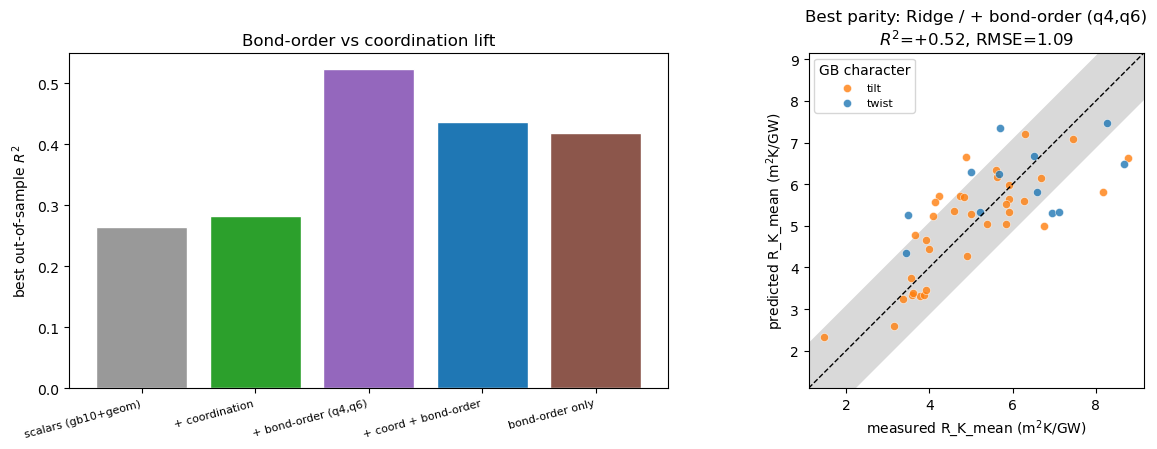

In [16]:
# Section 11b -- Steinhardt bond-order (q4, q6): does the next step in the
# coordination thread add independent signal? Same repeated 10-fold x 20-rep CV
# as sections 7 & 11.
import os

COORD_COLS = [f"{SUBSET}_coord_{s}" for s in ("under", "over", "mean", "std")]
BO_COLS    = [f"{SUBSET}_q{l}_{s}" for l in (4, 6) for s in ("mean", "std")]

def _find_cache(name):
    cands = [f"ml/{name}", name, os.path.join(os.path.dirname(DATASET), name)]
    return next((p for p in cands if os.path.exists(p)), None)

COORD_CACHE = _find_cache("gb10_coordination.csv")
BO_CACHE    = _find_cache("gb10_bondorder.csv")

if cv_results is None:
    print("No base CV results; skipping bond-order comparison.")
elif BO_CACHE is None:
    print("Bond-order cache not found. Generate it with:")
    print("    python ml/compute_bond_order.py")
else:
    mb = mldf.copy()
    if COORD_CACHE is not None:
        mb = mb.merge(pd.read_csv(COORD_CACHE), on="gb_label", how="left")
    mb = mb.merge(pd.read_csv(BO_CACHE), on="gb_label", how="left")

    need = list(BO_COLS) + (COORD_COLS if COORD_CACHE is not None else [])
    ok = mb[need].notna().all(axis=1).to_numpy()
    print(f"Bond-order present for {mb[BO_COLS].notna().all(axis=1).sum()}/{len(mb)} "
          f"modeled GBs; using {ok.sum()} rows with all compared features.")

    yb = mb.loc[ok, TARGET].to_numpy()
    feat_sets = {
        "scalars (gb10+geom)":  FEATURES,
        "+ coordination":       FEATURES + COORD_COLS,
        "+ bond-order (q4,q6)": FEATURES + BO_COLS,
        "+ coord + bond-order": FEATURES + COORD_COLS + BO_COLS,
        "bond-order only":      BO_COLS,
    }
    if COORD_CACHE is None:  # drop coordination comparisons if its cache is absent
        feat_sets = {k: v for k, v in feat_sets.items() if "coord" not in k}

    cmp_models = {k: build_models()[k] for k in ("Ridge", "KNN", "Ridge+KNN")}

    def bo_cv(cols):
        # Repeated 10-fold x 20-rep (shared repeated_oof); pooled R2 per rep.
        Xmat = mb.loc[ok, cols].to_numpy()
        res, oof = {}, {}
        for name, (pipe, grid) in cmp_models.items():
            pm, ps, r2s, rmses, _ = repeated_oof(Xmat, yb, pipe, grid, N_SPLITS, N_REPEATS)
            res[name] = {"RMSE_mean": rmses.mean(), "R2_mean": r2s.mean(), "R2_std": r2s.std()}
            oof[name] = pm
        return pd.DataFrame(res).T, oof

    tables, oofs = {}, {}
    for label, cols in feat_sets.items():
        tables[label], oofs[label] = bo_cv(cols)
        print(f"\n### {label}  (p={len(cols)})")
        print(tables[label].round(4).to_string())

    bfs, bm = max(((fs, m) for fs in tables for m in tables[fs].index),
                  key=lambda km: tables[km[0]].loc[km[1], "R2_mean"])
    print(f"\nBest: {bm} on '{bfs}'  ->  R2={tables[bfs].loc[bm,'R2_mean']:+.3f}")

    # (a) best-R2 per feature set; (b) parity for the best combo
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    fs_names = list(feat_sets)
    best_r2 = [tables[fs]["R2_mean"].max() for fs in fs_names]
    palette = ["0.6", "#2ca02c", "#9467bd", "#1f77b4", "#8c564b"]
    axes[0].bar(range(len(fs_names)), best_r2,
                color=palette[:len(fs_names)], edgecolor="white")
    axes[0].set_xticks(range(len(fs_names)))
    axes[0].set_xticklabels(fs_names, rotation=15, ha="right", fontsize=8)
    axes[0].axhline(0, color="k", lw=0.7)
    axes[0].set_ylabel("best out-of-sample $R^2$")
    axes[0].set_title("Bond-order vs coordination lift")

    pr = oofs[bfs][bm]; rmse = tables[bfs].loc[bm, "RMSE_mean"]
    lo = min(yb.min(), np.nanmin(pr)); hi = max(yb.max(), np.nanmax(pr))
    pad = 0.05 * (hi - lo); lo, hi = lo - pad, hi + pad
    chars = mb.loc[ok, "gb_character"].to_numpy()
    ax = axes[1]
    ax.fill_between([lo, hi], [lo - rmse, hi - rmse], [lo + rmse, hi + rmse],
                    color="0.85", zorder=0)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    for ch in pd.unique(chars):
        m = chars == ch
        ax.scatter(yb[m], pr[m], s=34, alpha=0.8, color=CHAR_COLORS.get(ch, "gray"),
                   edgecolor="white", linewidth=0.4, label=ch)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel(f"measured {TARGET_LABEL}"); ax.set_ylabel(f"predicted {TARGET_LABEL}")
    ax.legend(title="GB character", fontsize=8)
    ax.set_title(f"Best parity: {bm} / {bfs}\n$R^2$={tables[bfs].loc[bm,'R2_mean']:+.2f}, "
                 f"RMSE={rmse:.2f}")
    fig.tight_layout(); plt.show()


## 11c. Single-descriptor view — ŵ₄ alone tracks R_K

The third-order Steinhardt invariant $\hat w_4$ (a rotation-invariant fingerprint
of the local bonding *shape*; cached by `ml/compute_wl.py`) is the **strongest
single linear predictor** of R_K we have found: its slab-mean correlates with the
thermal boundary resistance at **r ≈ 0.66**, so one descriptor explains ~44 % of
the variance — versus ~0 % for the misorientation angle (section 5c). In the full
nested-CV model $\hat w_4,\hat w_6$ do **not** beat $q_4,q_6$ (they encode the
same local tetrahedral order, and the extra columns overfit 48 GBs), so the
production model stays at scalars + $q_4,q_6$ (section 11b). But as a single
variable it is the cleanest statement of the thesis: *local bonding order predicts
phonon scattering; macroscopic crystallography does not.*


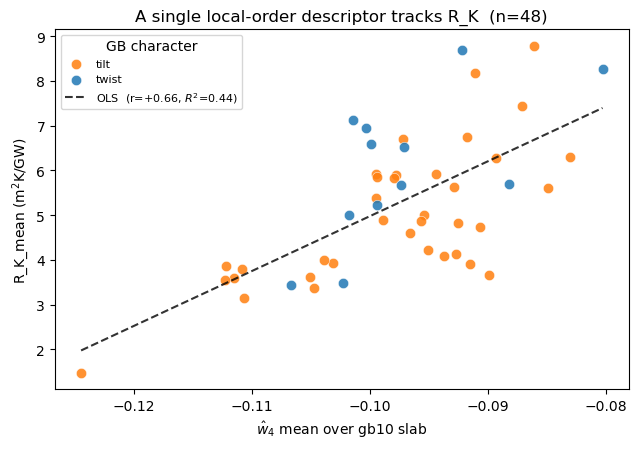

Pearson r(w4_mean, R_K) = +0.661  (p=3.1e-07);  single-feature R^2 = 0.437


In [17]:
# Section 11c -- single-descriptor view: the third-order Steinhardt invariant
# w4_mean alone tracks R_K (the strongest single linear predictor found).
import os

def _find(name):
    for p in (f"ml/{name}", name, os.path.join(os.path.dirname(DATASET), name)):
        if os.path.exists(p):
            return p
    return None

WL_CACHE = _find("gb10_wl.csv")
if WL_CACHE is None:
    print("w_l cache not found. Generate it with:  python ml/compute_wl.py")
else:
    wdf = df.merge(pd.read_csv(WL_CACHE), on="gb_label", how="left")
    sub = wdf[wdf["gb10_w4_mean"].notna() & wdf[TARGET].notna()]
    x = sub["gb10_w4_mean"].to_numpy(); y = sub[TARGET].to_numpy()
    r, p = stats.pearsonr(x, y)

    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    for ch in pd.unique(sub["gb_character"]):
        m = (sub["gb_character"] == ch).to_numpy()
        ax.scatter(x[m], y[m], s=55, alpha=0.85, color=CHAR_COLORS.get(ch, "gray"),
                   edgecolor="white", linewidth=0.4, label=ch)
    b1, b0 = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, b0 + b1 * xs, "k--", lw=1.5, alpha=0.8,
            label=f"OLS  (r={r:+.2f}, $R^2$={r**2:.2f})")
    ax.set_xlabel(r"$\hat w_4$ mean over gb10 slab")
    ax.set_ylabel(TARGET_LABEL)
    ax.legend(title="GB character", fontsize=8)
    ax.set_title(f"A single local-order descriptor tracks R_K  (n={len(sub)})")
    fig.tight_layout(); plt.show()
    print(f"Pearson r(w4_mean, R_K) = {r:+.3f}  (p={p:.1e});  "
          f"single-feature R^2 = {r**2:.3f}")


## 12. Out-of-sample comparison of the four front-runners — repeated 10-fold CV

The single-feature correlations (§11c) and the nested-CV lift (§11b) converge on
four candidate feature sets. Here they go head-to-head under **repeated 10-fold
cross-validation (20 random replications)** — a lower-variance estimate of
out-of-sample skill than a single split, with an honest uncertainty band. The
**production Ridge+KNN ensemble** is used for all four; each parity point is its
prediction averaged over the 20 replications. Error bars: the **vertical** bar is
the spread of the prediction across replications; the **horizontal** bar is the
standard error of the measured mean R_K ($R_{K,\mathrm{std}}/\sqrt{5}$ over the 5
rNEMD replicas) — the confidence interval of the quantity we predict, not the
per-replica spread.

The four sets trace the argument of §11–§11c:

- **Angular scalars** ($H_\phi + \sigma_\theta$) — the two *predictive* members
  of the original five disorder scalars, isolated from the dead radial ones
  ($A_\mathrm{RDF}, \rho$) that otherwise drag the full scalar model down.
- **Best single feature** ($q_6$ mean) — one number.
- **Bond-order** ($q_4, q_6$) — the four Steinhardt features; the sharpest
  angular probe.
- **Scalars + bond-order** — the production model.

Read across the panels: every set that measures *angular* disorder already
predicts R_K ($R^2 \approx 0.35$–0.42); de-noising the scalars and adding the
bond-order features tightens the parity to $R^2 \approx 0.49$. The lesson is that
the signal is **local angular order**, captured most sharply by bond-order —
macroscopic crystallography contributes nothing (§5, §5c).

Repeated 10-fold CV x 20 replications  (Ridge+KNN, n=48)

  H_phi + sigma_theta                R2 = +0.341 +/- 0.033   RMSE = 1.27   (p=2)
  q6                                 R2 = +0.383 +/- 0.031   RMSE = 1.23   (p=1)
  q4,q6 (bond-order)                 R2 = +0.418 +/- 0.038   RMSE = 1.19   (p=4)
  7 features + q4,q6                 R2 = +0.487 +/- 0.051   RMSE = 1.12   (p=11)


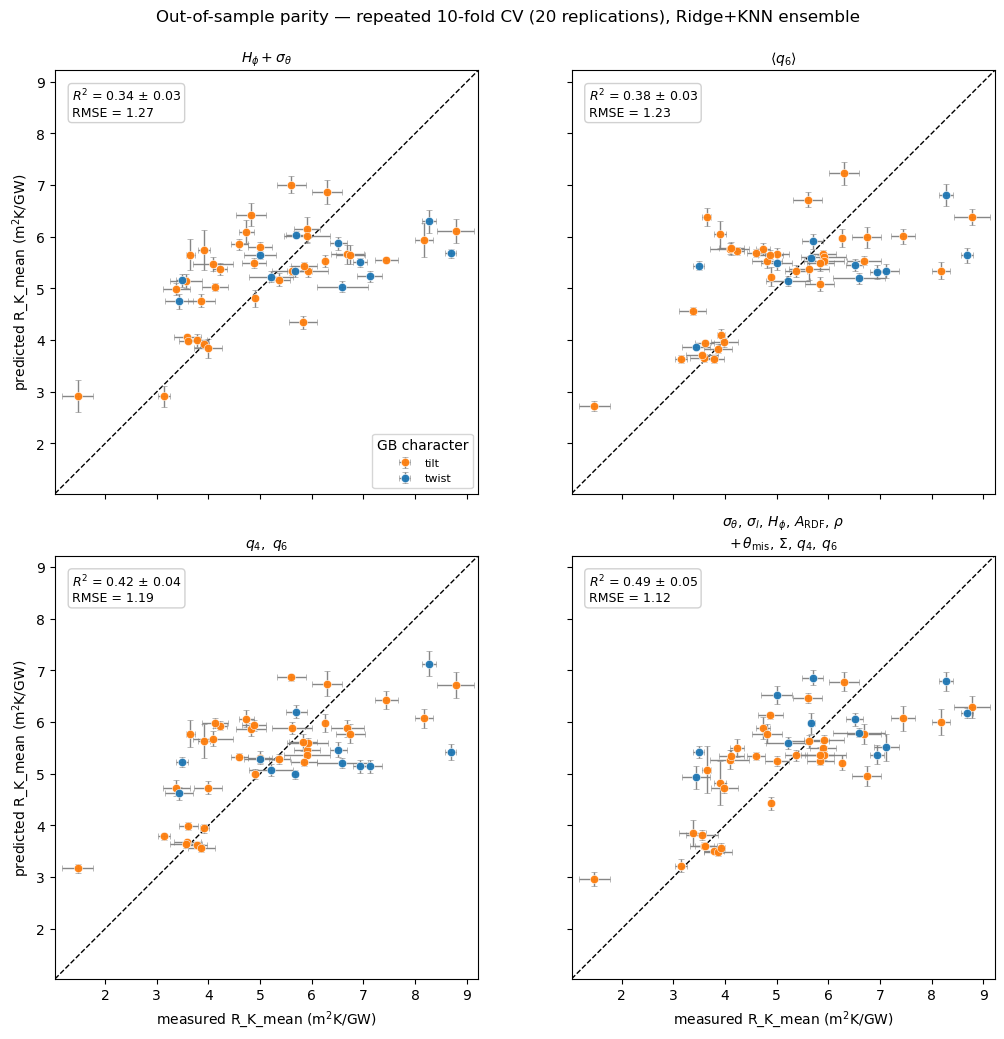

In [18]:
# Section 12 -- out-of-sample comparison of the four front-running feature sets
# under repeated 10-fold CV (the production Ridge+KNN ensemble throughout). Each
# point in the parity plots is its prediction averaged over the replications;
# error bars are the spread across replications (prediction stability).
import os
from sklearn.model_selection import RepeatedKFold

N_SPLITS, N_REPEATS = 10, 20

def _find_cache(name):
    cands = [f"ml/{name}", name, os.path.join(os.path.dirname(DATASET), name)]
    return next((p for p in cands if os.path.exists(p)), None)

BO_CACHE = _find_cache("gb10_bondorder.csv")
BO_COLS  = [f"{SUBSET}_q{l}_{s}" for l in (4, 6) for s in ("mean", "std")]

if BO_CACHE is None:
    print("Bond-order cache not found; run  python ml/compute_bond_order.py")
else:
    m12 = df.merge(pd.read_csv(BO_CACHE), on="gb_label", how="left")
    data = m12.dropna(subset=FEATURES + BO_COLS + [TARGET]).reset_index(drop=True)
    y12 = data[TARGET].to_numpy(); n12 = len(y12)
    chars = data["gb_character"].to_numpy()
    # x error = standard error of the *mean* R_K we predict (replica std / sqrt(N)),
    # i.e. the confidence interval of the mean, NOT the per-replica spread.
    N_REPLICAS = 5
    sem_meas = np.nan_to_num(data["R_K_std"].to_numpy(), nan=0.0) / np.sqrt(N_REPLICAS)

    # Panel titles are the actual descriptor symbols (LaTeX), not prose.
    PROD = ("$\\sigma_\\theta,\\,\\sigma_l,\\,H_\\phi,\\,A_\\mathrm{RDF},\\,\\rho$\n"
            "$+\\,\\theta_\\mathrm{mis},\\,\\Sigma,\\,q_4,\\,q_6$")
    FEATURE_SETS = {
        "$H_\\phi + \\sigma_\\theta$": [f"{SUBSET}_H_phi", f"{SUBSET}_sigma_theta"],
        "$\\langle q_6 \\rangle$":     [f"{SUBSET}_q6_mean"],
        "$q_4,\\ q_6$":                BO_COLS,
        PROD:                          FEATURES + BO_COLS,
    }
    PLAIN = ["H_phi + sigma_theta", "q6",
             "q4,q6 (bond-order)", "7 features + q4,q6"]

    pipe, grid = build_models()["Ridge+KNN"]

    def repeated_oof(cols):
        """Repeated K-fold OOF predictions + per-replication pooled R^2.

        RepeatedKFold yields N_REPEATS blocks of N_SPLITS folds; within each
        block every GB is held out exactly once, giving one full OOF vector ->
        one pooled R^2 per replication. Per-point predictions are accumulated
        across replications (mean = parity point, std = error bar)."""
        X = data[cols].to_numpy()
        rkf = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
        psum = np.zeros(n12); psq = np.zeros(n12); pcnt = np.zeros(n12)
        r2s = []; oof = np.full(n12, np.nan); k = 0
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for tr, te in rkf.split(X):
                gs = GridSearchCV(pipe, grid, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                                  scoring="neg_root_mean_squared_error", n_jobs=N_JOBS)
                gs.fit(X[tr], y12[tr]); p = gs.best_estimator_.predict(X[te])
                oof[te] = p; psum[te] += p; psq[te] += p ** 2; pcnt[te] += 1; k += 1
                if k == N_SPLITS:
                    r2s.append(r2_score(y12, oof)); oof = np.full(n12, np.nan); k = 0
        pmean = psum / pcnt
        pstd = np.sqrt(np.maximum(psq / pcnt - pmean ** 2, 0.0))
        return pmean, pstd, np.array(r2s)

    results = {lab: repeated_oof(cols) for lab, cols in FEATURE_SETS.items()}

    print(f"Repeated {N_SPLITS}-fold CV x {N_REPEATS} replications  (Ridge+KNN, n={n12})\n")
    for (lab, (pm, ps, r2)), pn in zip(results.items(), PLAIN):
        rmse = np.sqrt(np.mean((pm - y12) ** 2))
        print(f"  {pn:34s} R2 = {r2.mean():+.3f} +/- {r2.std():.3f}   "
              f"RMSE = {rmse:.2f}   (p={len(FEATURE_SETS[lab])})")

    # shared axis limits so the four panels are directly comparable
    allp = np.concatenate([pm for pm, _, _ in results.values()])
    lo = min(y12.min(), allp.min()); hi = max(y12.max(), allp.max())
    pad = 0.06 * (hi - lo); lo -= pad; hi += pad

    fig, axes = plt.subplots(2, 2, figsize=(11, 10.4), sharex=True, sharey=True)
    for ax, (lab, (pm, ps, r2)) in zip(axes.ravel(), results.items()):
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=1)
        for ch in pd.unique(chars):
            sel = chars == ch
            # x error = SEM of measured mean R_K (replica std/sqrt(5));
            # y error = spread of predictions across CV replications
            ax.errorbar(y12[sel], pm[sel], xerr=sem_meas[sel], yerr=ps[sel], fmt="o",
                        ms=6, alpha=0.95, color=CHAR_COLORS.get(ch, "gray"),
                        ecolor="0.5", elinewidth=1.0, capsize=2.5, mec="white", mew=0.4,
                        label=ch, zorder=3)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
        rmse = np.sqrt(np.mean((pm - y12) ** 2))
        ax.set_title(lab, fontsize=10)
        ax.text(0.04, 0.96, f"$R^2$ = {r2.mean():.2f} $\\pm$ {r2.std():.2f}\nRMSE = {rmse:.2f}",
                transform=ax.transAxes, va="top", ha="left", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.9))
    for ax in axes[-1, :]: ax.set_xlabel(f"measured {TARGET_LABEL}")
    for ax in axes[:, 0]: ax.set_ylabel(f"predicted {TARGET_LABEL}")
    axes[0, 0].legend(title="GB character", fontsize=8, loc="lower right")
    fig.suptitle(f"Out-of-sample parity — repeated {N_SPLITS}-fold CV "
                 f"({N_REPEATS} replications), Ridge+KNN ensemble", y=0.995, fontsize=12)
    fig.tight_layout(); plt.show()


## 12b. Linear view — Ridge only, with regression coefficients

Section 12 used the Ridge+KNN ensemble. Here the same repeated 10-fold comparison
uses a **pure Ridge** linear model — slightly *more* accurate on the full feature
set (the production panel reaches $R^2 \approx 0.54$; KNN adds noise in 11-D on
only 48 GBs) and, more importantly, fully **interpretable**: the features are
standardized, so the fitted coefficients are directly comparable and show which
descriptors carry the prediction.

The coefficient plot (standardized weights of the production model, averaged over
the CV folds; error bars = spread across folds) makes the thesis visual: **every
large coefficient is an angular descriptor** (green — $\mathrm{sd}(q_4)$,
$H_\phi$, $\langle q_4\rangle$, $\sigma_\theta$, $\mathrm{sd}(q_6)$,
$\langle q_6\rangle$), while the radial descriptors (red — $A_\mathrm{RDF}$,
$\rho$, $\sigma_l$) and the macroscopic crystallography (gray —
$\theta_\mathrm{mis}$, $\Sigma$) sit near zero.

*Caveat for interpretation:* the angular descriptors are mutually collinear, so
Ridge splits weight among them and the **sign of an individual bar can flip**
relative to its standalone correlation (e.g. $\sigma_\theta$, which correlates
*positively* with R_K on its own). Read the plot by **group magnitude** — angular
$\gg$ radial $\approx$ crystallographic — not by the sign of any single feature.

Ridge only — repeated 10-fold CV x 20 replications  (n=48)

  H_phi + sigma_theta                R2 = +0.296 +/- 0.028   RMSE = 1.31   (p=2)
  <q6> (best single)                 R2 = +0.403 +/- 0.018   RMSE = 1.22   (p=1)
  q4,q6 (bond-order)                 R2 = +0.410 +/- 0.045   RMSE = 1.19   (p=4)
  7 features + q4,q6 (production)    R2 = +0.523 +/- 0.058   RMSE = 1.05   (p=11)


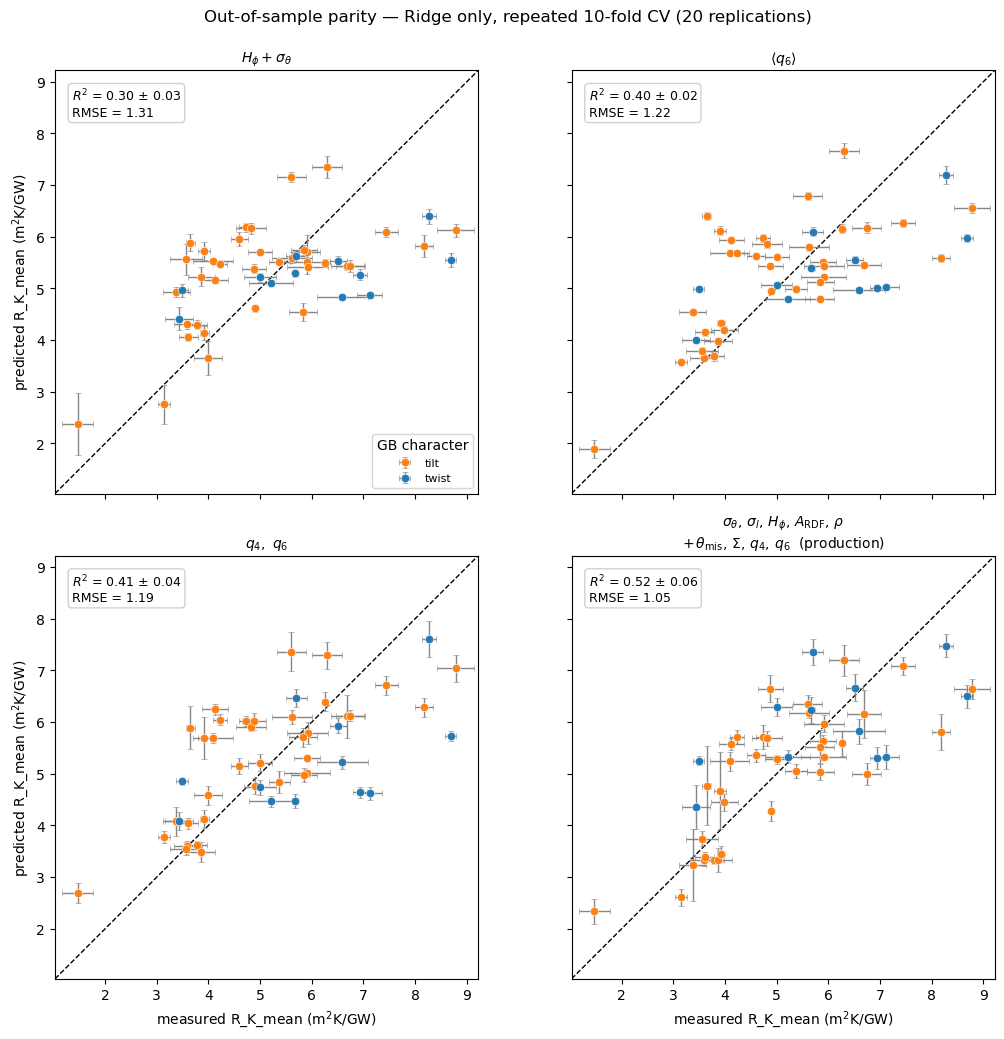

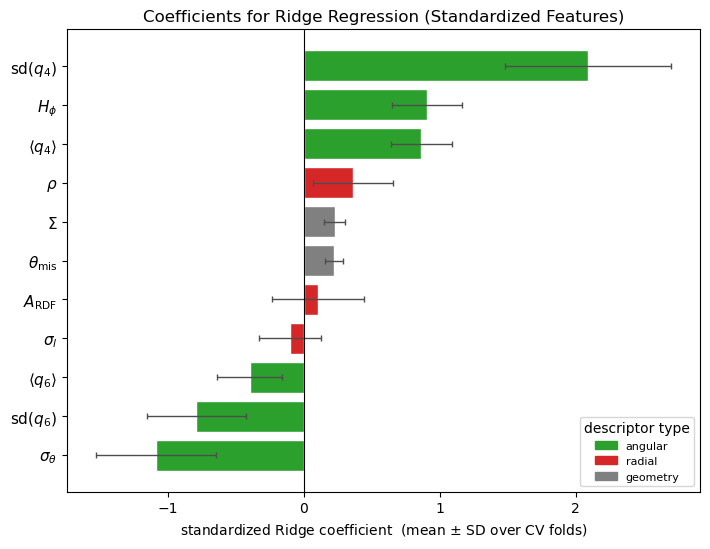

In [19]:
# Section 12b -- Ridge-only reproduction of the section-12 parity comparison, plus
# the standardized regression coefficients of the production model. A pure linear
# model trades a little accuracy for full interpretability: because the features
# are standardized, the coefficients are directly comparable and show *which*
# descriptors the model leans on.
import os
from sklearn.model_selection import RepeatedKFold

N_SPLITS, N_REPEATS = 10, 20
N_REPLICAS = 5

def _find_cache(name):
    cands = [f"ml/{name}", name, os.path.join(os.path.dirname(DATASET), name)]
    return next((p for p in cands if os.path.exists(p)), None)

BO_CACHE = _find_cache("gb10_bondorder.csv")
BO_COLS  = [f"{SUBSET}_q{l}_{s}" for l in (4, 6) for s in ("mean", "std")]

if BO_CACHE is None:
    print("Bond-order cache not found; run  python ml/compute_bond_order.py")
else:
    m12 = df.merge(pd.read_csv(BO_CACHE), on="gb_label", how="left")
    data = m12.dropna(subset=FEATURES + BO_COLS + [TARGET]).reset_index(drop=True)
    y12 = data[TARGET].to_numpy(); n12 = len(y12)
    chars = data["gb_character"].to_numpy()
    sem_meas = np.nan_to_num(data["R_K_std"].to_numpy(), nan=0.0) / np.sqrt(N_REPLICAS)
    PROD_COLS = FEATURES + BO_COLS

    PROD = ("$\\sigma_\\theta,\\,\\sigma_l,\\,H_\\phi,\\,A_\\mathrm{RDF},\\,\\rho$\n"
            "$+\\,\\theta_\\mathrm{mis},\\,\\Sigma,\\,q_4,\\,q_6$  (production)")
    FEATURE_SETS = {
        "$H_\\phi + \\sigma_\\theta$": [f"{SUBSET}_H_phi", f"{SUBSET}_sigma_theta"],
        "$\\langle q_6 \\rangle$":     [f"{SUBSET}_q6_mean"],
        "$q_4,\\ q_6$":                BO_COLS,
        PROD:                          PROD_COLS,
    }
    PLAIN = ["H_phi + sigma_theta", "<q6> (best single)",
             "q4,q6 (bond-order)", "7 features + q4,q6 (production)"]

    pipe, grid = build_models()["Ridge"]   # pure Ridge this time

    def repeated_oof(cols, collect_coef=False):
        X = data[cols].to_numpy()
        rkf = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
        psum = np.zeros(n12); psq = np.zeros(n12); pcnt = np.zeros(n12)
        r2s = []; oof = np.full(n12, np.nan); k = 0; coefs = []
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for tr, te in rkf.split(X):
                gs = GridSearchCV(pipe, grid, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                                  scoring="neg_root_mean_squared_error", n_jobs=N_JOBS)
                gs.fit(X[tr], y12[tr]); est = gs.best_estimator_
                p = est.predict(X[te]); oof[te] = p; psum[te] += p; psq[te] += p ** 2; pcnt[te] += 1; k += 1
                if collect_coef:
                    coefs.append(est.named_steps["m"].coef_.ravel())
                if k == N_SPLITS:
                    r2s.append(r2_score(y12, oof)); oof = np.full(n12, np.nan); k = 0
        pmean = psum / pcnt; pstd = np.sqrt(np.maximum(psq / pcnt - pmean ** 2, 0.0))
        return pmean, pstd, np.array(r2s), (np.array(coefs) if collect_coef else None)

    results = {}; coef_mat = None
    for lab, cols in FEATURE_SETS.items():
        pm, ps, r2, cf = repeated_oof(cols, collect_coef=(cols is PROD_COLS))
        results[lab] = (pm, ps, r2)
        if cf is not None:
            coef_mat = cf

    print(f"Ridge only — repeated {N_SPLITS}-fold CV x {N_REPEATS} replications  (n={n12})\n")
    for (lab, (pm, ps, r2)), pn in zip(results.items(), PLAIN):
        rmse = np.sqrt(np.mean((pm - y12) ** 2))
        print(f"  {pn:34s} R2 = {r2.mean():+.3f} +/- {r2.std():.3f}   "
              f"RMSE = {rmse:.2f}   (p={len(FEATURE_SETS[lab])})")

    # ---- Figure 1: parity grid (same layout as section 12, Ridge) ----
    allp = np.concatenate([pm for pm, _, _ in results.values()])
    lo = min(y12.min(), allp.min()); hi = max(y12.max(), allp.max())
    pad = 0.06 * (hi - lo); lo -= pad; hi += pad
    fig, axes = plt.subplots(2, 2, figsize=(11, 10.4), sharex=True, sharey=True)
    for ax, (lab, (pm, ps, r2)) in zip(axes.ravel(), results.items()):
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=1)
        for ch in pd.unique(chars):
            sel = chars == ch
            ax.errorbar(y12[sel], pm[sel], xerr=sem_meas[sel], yerr=ps[sel], fmt="o",
                        ms=6, alpha=0.95, color=CHAR_COLORS.get(ch, "gray"),
                        ecolor="0.5", elinewidth=1.0, capsize=2.5, mec="white", mew=0.4,
                        label=ch, zorder=3)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
        rmse = np.sqrt(np.mean((pm - y12) ** 2))
        ax.set_title(lab, fontsize=10)
        ax.text(0.04, 0.96, f"$R^2$ = {r2.mean():.2f} $\\pm$ {r2.std():.2f}\nRMSE = {rmse:.2f}",
                transform=ax.transAxes, va="top", ha="left", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.9))
    for ax in axes[-1, :]: ax.set_xlabel(f"measured {TARGET_LABEL}")
    for ax in axes[:, 0]: ax.set_ylabel(f"predicted {TARGET_LABEL}")
    axes[0, 0].legend(title="GB character", fontsize=8, loc="lower right")
    fig.suptitle(f"Out-of-sample parity — Ridge only, repeated {N_SPLITS}-fold CV "
                 f"({N_REPEATS} replications)", y=0.995, fontsize=12)
    fig.tight_layout(); plt.show()

    # ---- Figure 2: standardized Ridge coefficients of the production model ----
    LABELS = {f"{SUBSET}_sigma_theta": r"$\sigma_\theta$", f"{SUBSET}_sigma_l": r"$\sigma_l$",
              f"{SUBSET}_H_phi": r"$H_\phi$", f"{SUBSET}_A_RDF": r"$A_\mathrm{RDF}$",
              f"{SUBSET}_rho": r"$\rho$", "misorientation_deg": r"$\theta_\mathrm{mis}$",
              "sigma": r"$\Sigma$", f"{SUBSET}_q4_mean": r"$\langle q_4\rangle$",
              f"{SUBSET}_q4_std": r"$\mathrm{sd}(q_4)$", f"{SUBSET}_q6_mean": r"$\langle q_6\rangle$",
              f"{SUBSET}_q6_std": r"$\mathrm{sd}(q_6)$"}
    ANGULAR = {f"{SUBSET}_sigma_theta", f"{SUBSET}_H_phi", f"{SUBSET}_q4_mean",
               f"{SUBSET}_q4_std", f"{SUBSET}_q6_mean", f"{SUBSET}_q6_std"}
    RADIAL  = {f"{SUBSET}_sigma_l", f"{SUBSET}_A_RDF", f"{SUBSET}_rho"}
    def group(c): return "angular" if c in ANGULAR else "radial" if c in RADIAL else "geometry"
    GCOLOR = {"angular": "#2ca02c", "radial": "#d62728", "geometry": "0.5"}

    mean_c = coef_mat.mean(axis=0); std_c = coef_mat.std(axis=0)
    order = np.argsort(mean_c)
    cols_sorted = [PROD_COLS[i] for i in order]
    ypos = np.arange(len(order))
    fig2, axc = plt.subplots(figsize=(7.2, 5.6))
    axc.barh(ypos, mean_c[order], xerr=std_c[order], color=[GCOLOR[group(c)] for c in cols_sorted],
             edgecolor="white", error_kw=dict(ecolor="0.3", elinewidth=1, capsize=2))
    axc.axvline(0, color="k", lw=0.8)
    axc.set_yticks(ypos); axc.set_yticklabels([LABELS[c] for c in cols_sorted], fontsize=11)
    axc.set_xlabel("standardized Ridge coefficient  (mean $\\pm$ SD over CV folds)")
    axc.set_title("Coefficients for Ridge Regression (Standardized Features)")
    from matplotlib.patches import Patch
    axc.legend(handles=[Patch(color=GCOLOR[g], label=g) for g in ("angular", "radial", "geometry")],
               fontsize=8, loc="lower right", title="descriptor type")
    fig2.tight_layout(); plt.show()


### 12c. Bond-order diagnostics — collinearity and the univariate signal

Two views that explain *why* the individual Ridge signs in 12b cannot be read at
face value, and what the sign-stable physics actually is.

**Pair-plot (Figure 1)** — the four bond-order descriptors are mutually
collinear: $\langle q_6\rangle \leftrightarrow \mathrm{sd}(q_6)$ is $r=-0.97$, and
$\mathrm{sd}(q_4)$ tracks both ($\pm0.89$). Four predictors that span essentially
one "disorder" axis are exactly the situation in which Ridge *splits* weight and
flips individual signs (the suppressor effect flagged in 12b).

**Univariate regressions (Figure 2)** — the honest, collinearity-free reading.
More disorder $\to$ higher $R_K$, and it shows up consistently: $\langle q_6\rangle$
falls below its diamond-cubic ideal (0.629) and correlates **negatively**
($r=-0.67$); $\mathrm{sd}(q_4)$ and $\mathrm{sd}(q_6)$ both correlate **positively**
($+0.65,\,+0.62$). The lone weak panel is $\langle q_4\rangle$ ($r=-0.21$,
$p\approx0.15$): its mean is pinned at the ideal 0.509 and barely moves, so the
$q_4$ signal lives in its **spread**, not its mean — which is why $q_4$ and $q_6$
need not behave symmetrically.

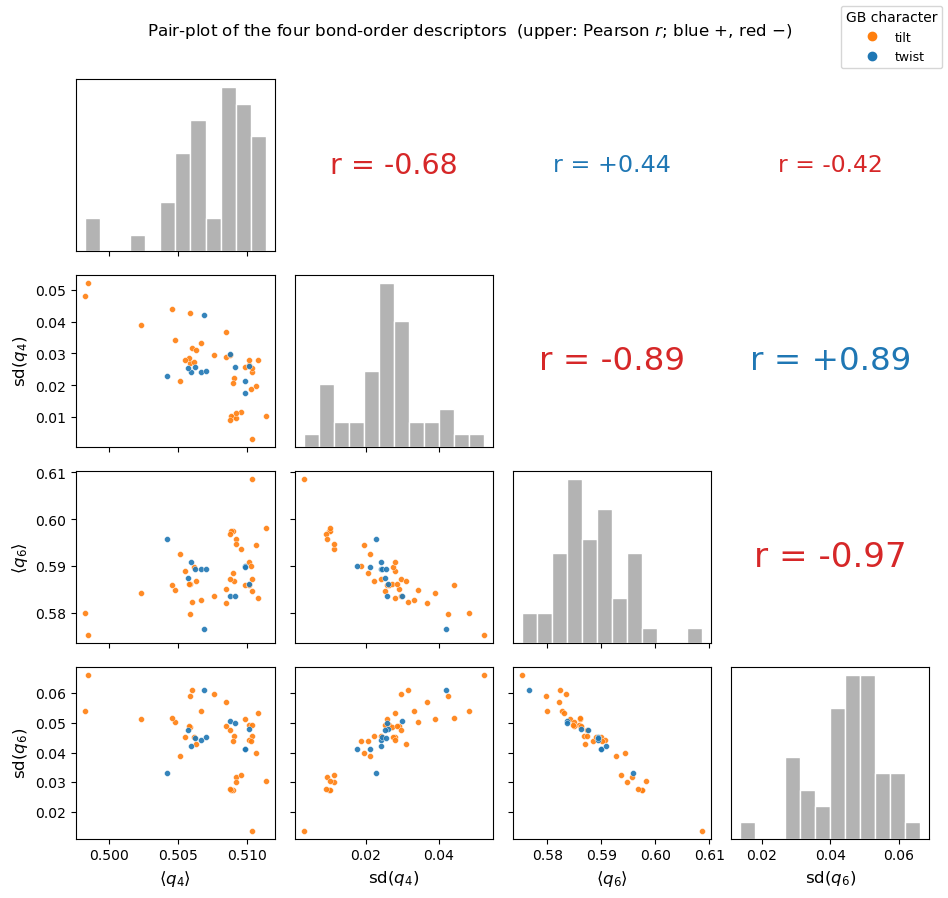

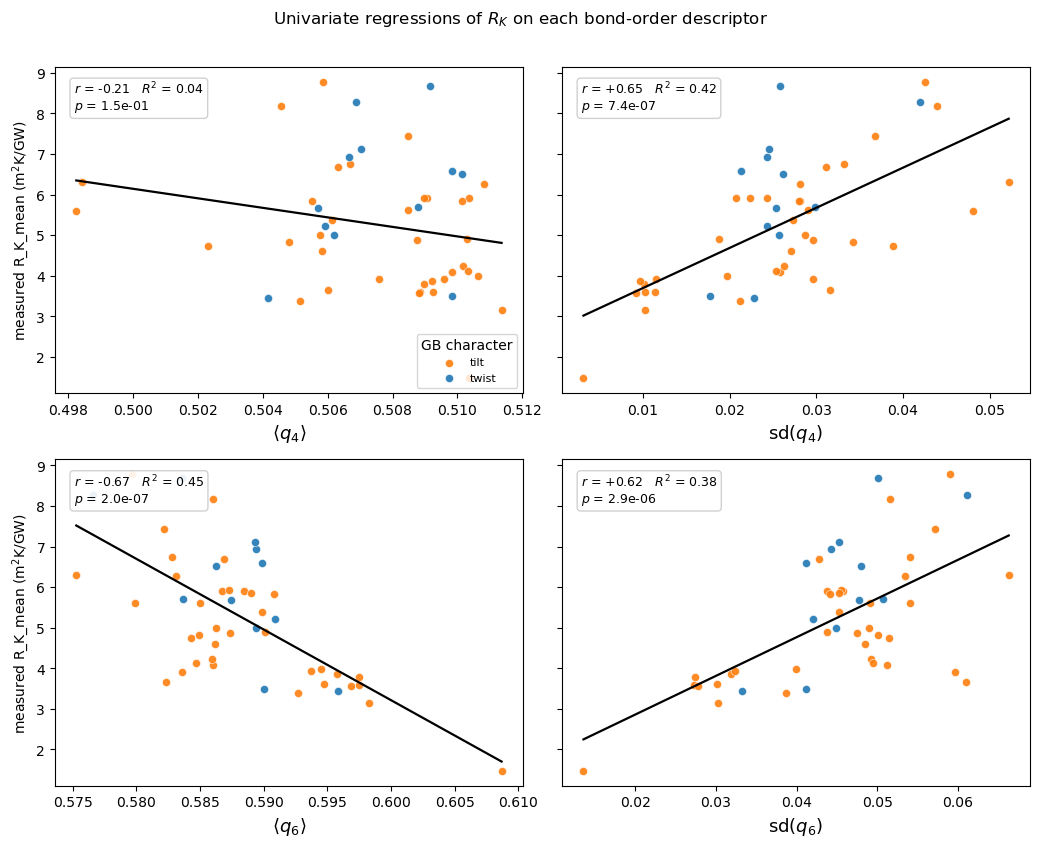

In [20]:
# Section 12c -- diagnostics behind the bond-order coefficients of 12b:
#   (1) a pair-plot of the four q-descriptors with pairwise Pearson r, exposing
#       the collinearity that makes the individual Ridge signs unreliable; and
#   (2) the four univariate R_K regressions -- the sign-stable physical reading
#       the multivariate coefficients should be interpreted against.
# Reuses `data`, `y12`, `BO_COLS`, `chars` from section 12b (run it first).
if "data" not in globals() or "BO_COLS" not in globals():
    print("Run section 12b first (it defines `data`, `y12`, `BO_COLS`, `chars`).")
else:
    QLAB = {f"{SUBSET}_q4_mean": r"$\langle q_4\rangle$", f"{SUBSET}_q4_std": r"$\mathrm{sd}(q_4)$",
            f"{SUBSET}_q6_mean": r"$\langle q_6\rangle$", f"{SUBSET}_q6_std": r"$\mathrm{sd}(q_6)$"}
    Q = BO_COLS                       # [q4_mean, q4_std, q6_mean, q6_std]
    nq = len(Q); Xq = data[Q].to_numpy()

    # ---- Figure 1: pair-plot with pairwise Pearson r ----
    fig, axes = plt.subplots(nq, nq, figsize=(9.5, 9.0))
    for i in range(nq):
        for j in range(nq):
            ax = axes[i, j]
            if i == j:                                  # diagonal: histogram
                ax.hist(Xq[:, i], bins=12, color="0.7", edgecolor="white"); ax.set_yticks([])
            elif i > j:                                 # lower triangle: scatter
                for ch in pd.unique(chars):
                    sel = chars == ch
                    ax.scatter(Xq[sel, j], Xq[sel, i], s=18, alpha=0.9,
                               color=CHAR_COLORS.get(ch, "gray"), edgecolor="white",
                               linewidth=0.3, label=ch)
            else:                                       # upper triangle: correlation
                r = np.corrcoef(Xq[:, j], Xq[:, i])[0, 1]
                ax.text(0.5, 0.5, f"r = {r:+.2f}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=11 + 14 * abs(r),
                        color="#d62728" if r < 0 else "#1f77b4")
                ax.set_xticks([]); ax.set_yticks([])
                for s in ax.spines.values(): s.set_visible(False)
            if i == nq - 1: ax.set_xlabel(QLAB[Q[j]], fontsize=12)
            if j == 0 and i != 0: ax.set_ylabel(QLAB[Q[i]], fontsize=12)
            if i != nq - 1: ax.set_xticklabels([])
            if j != 0: ax.set_yticklabels([])
    handles = [plt.Line2D([], [], marker="o", ls="", color=CHAR_COLORS.get(c, "gray"), label=c)
               for c in pd.unique(chars)]
    fig.legend(handles=handles, title="GB character", loc="upper right", fontsize=9, frameon=True)
    fig.suptitle("Pair-plot of the four bond-order descriptors  "
                 "(upper: Pearson $r$; blue $+$, red $-$)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

    # ---- Figure 2: univariate R_K regressions, one per descriptor ----
    fig2, axes2 = plt.subplots(2, 2, figsize=(10.5, 8.6), sharey=True)
    for ax, c in zip(axes2.ravel(), Q):
        x = data[c].to_numpy()
        for ch in pd.unique(chars):
            sel = chars == ch
            ax.scatter(x[sel], y12[sel], s=34, alpha=0.9, color=CHAR_COLORS.get(ch, "gray"),
                       edgecolor="white", linewidth=0.4, label=ch)
        lr = stats.linregress(x, y12); xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, lr.intercept + lr.slope * xs, "k-", lw=1.6, zorder=1)
        ax.set_xlabel(QLAB[c], fontsize=13)
        ax.text(0.04, 0.96, f"$r$ = {lr.rvalue:+.2f}   $R^2$ = {lr.rvalue ** 2:.2f}\n"
                f"$p$ = {lr.pvalue:.1e}", transform=ax.transAxes, va="top", ha="left",
                fontsize=9, bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.9))
    for ax in axes2[:, 0]: ax.set_ylabel(f"measured {TARGET_LABEL}")
    axes2[0, 0].legend(title="GB character", fontsize=8, loc="lower right")
    fig2.suptitle("Univariate regressions of $R_K$ on each bond-order descriptor", fontsize=12)
    fig2.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

### 12d. Model bake-off — are we leaving accuracy on the table?

The whole pipeline rides on Ridge (and the Ridge+KNN ensemble). This section
checks that choice head-to-head on the **full predictor set** (7 scalar/geometry
features + $q_4,q_6$ = 11 predictors): a linear model (**Ridge**), a local one
(**KNN**), and two tree ensembles (**RandomForest**, **XGBoost**), each tuned by
inner 3-fold grid search inside repeated nested CV.

Ridge and KNN get the full **10-fold × 20 reps**; the higher-variance, slower
tree ensembles get a lighter **5-fold × 10 reps** (fewer/larger folds and fewer
replications — looser error bars but a fair read at a fraction of the runtime).
The table reports pooled-OOF $R^2$ (mean ± SD across replications) and RMSE; the
parity grid below is in the same style as §12 / §12b.

With only 48 GBs the flexible learners overfit the 11-D space and regress toward
the mean — the linear model is the right operating point, not a fallback.

Model bake-off on the full predictor set  (p=11, n=48)

  Ridge          R2 = +0.523 +/- 0.058   RMSE = 1.05   (10-fold x 20)
  KNN            R2 = +0.251 +/- 0.053   RMSE = 1.35   (10-fold x 20)
  RandomForest   R2 = +0.238 +/- 0.059   RMSE = 1.35   (5-fold x 10)
  XGBoost        R2 = +0.031 +/- 0.117   RMSE = 1.48   (5-fold x 10)


,R2_mean,R2_sd,RMSE,CV
model,,,,
Ridge,0.523,0.058,1.05,10-fold x 20
KNN,0.251,0.053,1.35,10-fold x 20
RandomForest,0.238,0.059,1.35,5-fold x 10
XGBoost,0.031,0.117,1.48,5-fold x 10


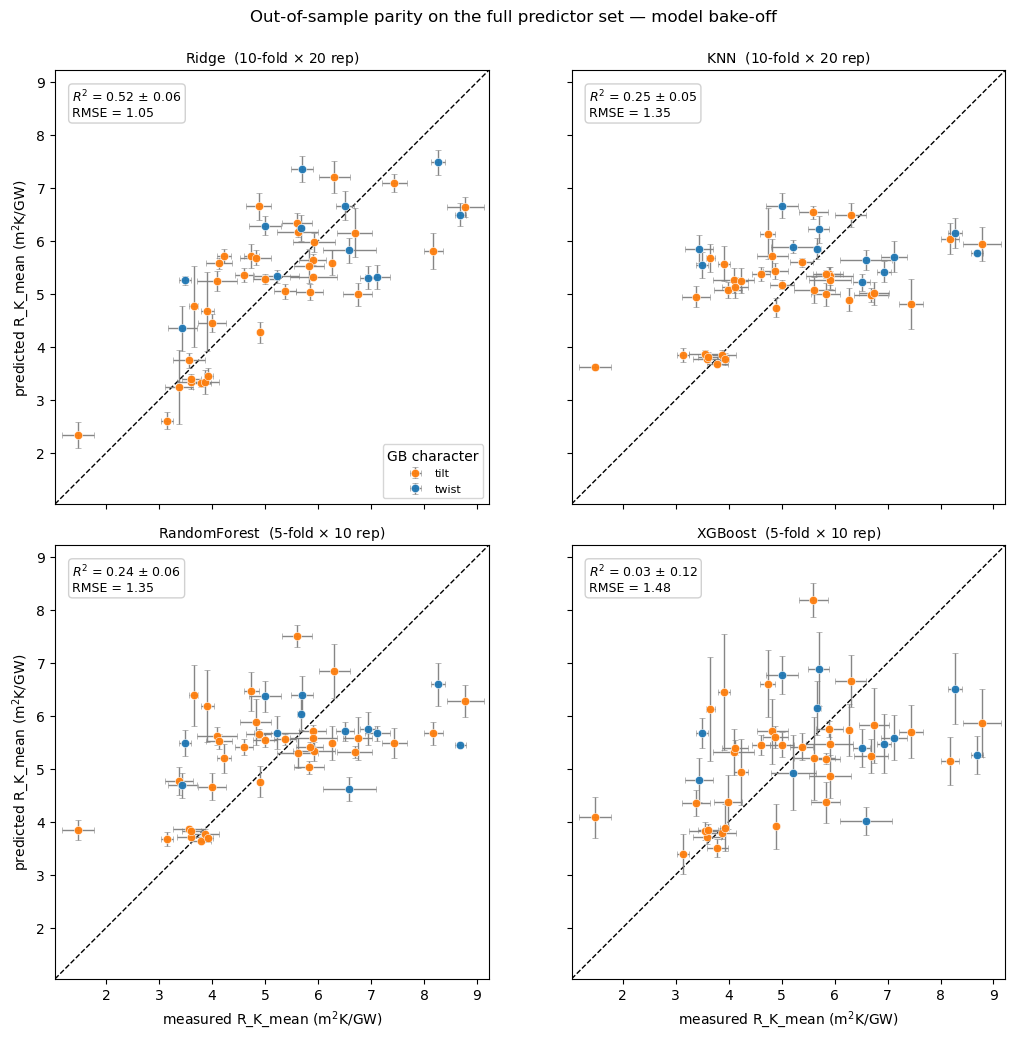

In [21]:
# Section 12d -- model bake-off on the FULL predictor set (7 scalar/geometry + q4,q6).
# Are we leaving accuracy on the table? Compare a linear (Ridge), a local (KNN),
# and two tree ensembles (RandomForest, XGBoost) under repeated nested CV, each
# tuned by inner 3-fold grid search. Ridge/KNN get 10-fold x 20 reps; the slower,
# higher-variance trees get 5-fold x 10 reps. Reuses `data`, `y12`, `n12`, `chars`,
# `sem_meas`, `BO_COLS` from section 12 / 12b (run one of them first).
if "data" not in globals() or "BO_COLS" not in globals():
    print("Run section 12 or 12b first (defines `data`, `y12`, `BO_COLS`, `chars`, `sem_meas`).")
else:
    PROD_COLS = FEATURES + BO_COLS
    CV_SCHEME = {"Ridge": (10, 20), "KNN": (10, 20),
                 "RandomForest": (5, 10), "XGBoost": (5, 10)}
    MODELS = build_models()

    def repeated_oof_model(pipe, grid, n_splits, n_repeats):
        """Repeated K-fold OOF on PROD_COLS: per-point prediction mean/spread
        across replications + one pooled R^2 per replication (see section 12)."""
        X = data[PROD_COLS].to_numpy()
        rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
        psum = np.zeros(n12); psq = np.zeros(n12); pcnt = np.zeros(n12)
        r2s = []; oof = np.full(n12, np.nan); k = 0
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for tr, te in rkf.split(X):
                gs = GridSearchCV(pipe, grid, cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                                  scoring="neg_root_mean_squared_error", n_jobs=N_JOBS)
                gs.fit(X[tr], y12[tr]); p = gs.best_estimator_.predict(X[te])
                oof[te] = p; psum[te] += p; psq[te] += p ** 2; pcnt[te] += 1; k += 1
                if k == n_splits:
                    r2s.append(r2_score(y12, oof)); oof = np.full(n12, np.nan); k = 0
        pmean = psum / pcnt
        pstd = np.sqrt(np.maximum(psq / pcnt - pmean ** 2, 0.0))
        return pmean, pstd, np.array(r2s)

    bake = {}
    for name in ("Ridge", "KNN", "RandomForest", "XGBoost"):
        ns, nr = CV_SCHEME[name]; pipe, grid = MODELS[name]
        bake[name] = (repeated_oof_model(pipe, grid, ns, nr), (ns, nr))

    # ---- performance table ----
    rows = []
    print(f"Model bake-off on the full predictor set  (p={len(PROD_COLS)}, n={n12})\n")
    for name, ((pm, ps, r2), (ns, nr)) in bake.items():
        rmse = np.sqrt(np.mean((pm - y12) ** 2))
        print(f"  {name:14s} R2 = {r2.mean():+.3f} +/- {r2.std():.3f}   "
              f"RMSE = {rmse:.2f}   ({ns}-fold x {nr})")
        rows.append({"model": name, "R2_mean": r2.mean(), "R2_sd": r2.std(),
                     "RMSE": rmse, "CV": f"{ns}-fold x {nr}"})
    perf = pd.DataFrame(rows).set_index("model")
    try:
        from IPython.display import display
        display(perf.round({"R2_mean": 3, "R2_sd": 3, "RMSE": 2}))
    except Exception:
        pass

    # ---- parity grid (same style as section 12 / 12b) ----
    allp = np.concatenate([pm for ((pm, _, _), _) in bake.values()])
    lo = min(y12.min(), allp.min()); hi = max(y12.max(), allp.max())
    pad = 0.06 * (hi - lo); lo -= pad; hi += pad
    fig, axes = plt.subplots(2, 2, figsize=(11, 10.4), sharex=True, sharey=True)
    for ax, (name, ((pm, ps, r2), (ns, nr))) in zip(axes.ravel(), bake.items()):
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, zorder=1)
        for ch in pd.unique(chars):
            sel = chars == ch
            ax.errorbar(y12[sel], pm[sel], xerr=sem_meas[sel], yerr=ps[sel], fmt="o",
                        ms=6, alpha=0.95, color=CHAR_COLORS.get(ch, "gray"),
                        ecolor="0.5", elinewidth=1.0, capsize=2.5, mec="white", mew=0.4,
                        label=ch, zorder=3)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
        rmse = np.sqrt(np.mean((pm - y12) ** 2))
        ax.set_title(f"{name}  ({ns}-fold $\\times$ {nr} rep)", fontsize=10)
        ax.text(0.04, 0.96, f"$R^2$ = {r2.mean():.2f} $\\pm$ {r2.std():.2f}\nRMSE = {rmse:.2f}",
                transform=ax.transAxes, va="top", ha="left", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.9))
    for ax in axes[-1, :]: ax.set_xlabel(f"measured {TARGET_LABEL}")
    for ax in axes[:, 0]: ax.set_ylabel(f"predicted {TARGET_LABEL}")
    axes[0, 0].legend(title="GB character", fontsize=8, loc="lower right")
    fig.suptitle("Out-of-sample parity on the full predictor set — model bake-off",
                 y=0.995, fontsize=12)
    fig.tight_layout(); plt.show()